# Employee Stability Prediction with Regularization
## A Beginner's Guide to Regression and Regularization

**Problem Statement:** Develop a predictive model to classify employees as likely to stay or leave the company.

**Dataset:** 900 employees with 15 features including job satisfaction, performance rating, years at company, work-life balance, and more.

**Goal:** Learn the difference between regression and regularization, and implement multiple regularization techniques to prevent overfitting.

In [20]:
# Import Required Libraries
# ===========================
import pandas as pd              # For data manipulation and analysis
import numpy as np               # For numerical computations
import matplotlib.pyplot as plt  # For plotting charts and graphs
import seaborn as sns            # For enhanced visualization
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score  # For splitting data and cross-validation
from sklearn.preprocessing import StandardScaler  # For scaling features (important for regularization!)
from sklearn.linear_model import LogisticRegression  # For classification models
from sklearn.linear_model import SGDClassifier  # For Elastic Net implementation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve  # For model evaluation

import warnings

# Suppress all warnings from libraries
# ====================================
# This line configures Python to silently suppress all warnings
# WITHOUT this: We'd see 5-10+ warnings from scikit-learn during training
# WITH this: Clean output focused on results
#
# DETAILED BREAKDOWN:
#   warnings              = Python's warning handling module
#   .filterwarnings()     = Function to configure warning behavior
#   ('ignore')            = Action: suppress all warnings silently
#
# Why we use this here:
#   1. Jupyter notebooks benefit from clean output
#   2. scikit-learn generates many deprecation warnings we can't fix
#   3. We understand the warnings come from dependencies
#   4. This is educational code, not production
#   5. Important: In production code, you should investigate warnings!
#
# Alternative approaches (when not to use 'ignore'):
#   warnings.filterwarnings('error')   # Convert warnings to errors (testing)
#   warnings.filterwarnings('once')    # Show each warning once (long scripts)
#   No call at all                     # Show all warnings (debugging)
#
warnings.filterwarnings('ignore')

# Set visualization style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [28]:
# DETAILED IMPORT EXPLANATIONS
# ============================

print("=" * 100)
print("COMPREHENSIVE GUIDE TO ALL IMPORTS")
print("=" * 100)

# IMPORT GROUP 1: Data Manipulation & Analysis
# =============================================
print("\n" + "━" * 100)
print("GROUP 1: DATA MANIPULATION & ANALYSIS")
print("━" * 100)

pandas_info = """
LIBRARY: pandas
Import:  import pandas as pd
─────────────────────────────────────────────────────────────────────────

PURPOSE:
  • Data manipulation and analysis library
  • Works with tabular data (like Excel spreadsheets)
  • Handles CSV, JSON, SQL, and many other formats
  
KEY CONCEPTS:
  • DataFrame: 2D table with rows and columns (like a spreadsheet)
  • Series: 1D array of data (like a single column)
  • Index: Labels for rows and columns
  
MAIN FUNCTIONS WE USE:
  ✓ pd.read_csv()          → Load data from CSV file
  ✓ df.head()              → View first N rows
  ✓ df.describe()          → Statistical summary
  ✓ df.drop()              → Remove columns/rows
  ✓ df.isnull()            → Check missing values
  ✓ df.value_counts()      → Count unique values
  
WHY WE NEED IT:
  • Load employee data from CSV file
  • Explore and understand data structure
  • Separate features from target variable
  • Handle missing data
  
INSTALLED: Yes (included with most Python distributions)
VERSION CHECK: import pandas as pd; print(pd.__version__)
"""

print(pandas_info)

numpy_info = """
LIBRARY: numpy
Import:  import numpy as np
─────────────────────────────────────────────────────────────────────────

PURPOSE:
  • Numerical computing library
  • Efficient operations on large arrays
  • Foundation for scientific Python
  
KEY CONCEPTS:
  • ndarray: N-dimensional array (fast, memory-efficient)
  • Broadcasting: Operating on arrays of different shapes
  • Vectorization: Applying operations without loops
  
MAIN FUNCTIONS WE USE:
  ✓ np.sum()               → Sum all elements
  ✓ np.mean()              → Calculate mean
  ✓ np.std()               → Calculate standard deviation
  ✓ np.abs()               → Absolute values
  ✓ np.max(), np.min()     → Find maximum/minimum
  ✓ np.argsort()           → Sort and get indices
  ✓ np.bincount()          → Count occurrences
  ✓ np.where()             → Find indices matching condition
  
WHY WE NEED IT:
  • Efficient numerical computations
  • Underlying library for pandas and scikit-learn
  • Handle large arrays of numbers
  • Mathematical operations on data
  
PERFORMANCE: Much faster than native Python lists
MEMORY: More memory-efficient for large datasets
"""

print(numpy_info)

COMPREHENSIVE GUIDE TO ALL IMPORTS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GROUP 1: DATA MANIPULATION & ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LIBRARY: pandas
Import:  import pandas as pd
─────────────────────────────────────────────────────────────────────────

PURPOSE:
  • Data manipulation and analysis library
  • Works with tabular data (like Excel spreadsheets)
  • Handles CSV, JSON, SQL, and many other formats

KEY CONCEPTS:
  • DataFrame: 2D table with rows and columns (like a spreadsheet)
  • Series: 1D array of data (like a single column)
  • Index: Labels for rows and columns

MAIN FUNCTIONS WE USE:
  ✓ pd.read_csv()          → Load data from CSV file
  ✓ df.head()              → View first N rows
  ✓ df.describe()          → Statistical summary
  ✓ df.drop()              → Remove columns/rows
  ✓ df.isnull()            → Check missing values
 

In [29]:
# IMPORT GROUP 2: Data Visualization
# ===================================
print("\n" + "━" * 100)
print("GROUP 2: DATA VISUALIZATION")
print("━" * 100)

matplotlib_info = """
LIBRARY: matplotlib
Import:  import matplotlib.pyplot as plt
─────────────────────────────────────────────────────────────────────────

PURPOSE:
  • Create static, animated, and interactive visualizations
  • Foundation library for Python plotting
  • Used by many other libraries (seaborn, pandas)
  
ORGANIZATION:
  • matplotlib.pyplot: Simple interface (most common)
  • matplotlib.figure: Object-oriented approach (advanced)
  
MAIN FUNCTIONS WE USE:
  ✓ plt.subplots()         → Create figure and axes
  ✓ plt.bar()              → Bar charts
  ✓ plt.plot()             → Line plots
  ✓ plt.scatter()          → Scatter plots
  ✓ plt.title()            → Add title
  ✓ plt.xlabel/ylabel()    → Label axes
  ✓ plt.legend()           → Add legend
  ✓ plt.show()             → Display plot
  ✓ plt.tight_layout()     → Auto-adjust spacing
  
WHY WE NEED IT:
  • Compare model performance visually
  • Create ROC curves for classification
  • Visualize coefficient comparisons
  • Make results interpretable
  
TYPICAL WORKFLOW:
  1. Create figure: fig, ax = plt.subplots()
  2. Add data: ax.plot(x, y)
  3. Format: ax.set_xlabel('X Label')
  4. Display: plt.show()
"""

print(matplotlib_info)

seaborn_info = """
LIBRARY: seaborn
Import:  import seaborn as sns
─────────────────────────────────────────────────────────────────────────

PURPOSE:
  • Statistical data visualization
  • Built on top of matplotlib (makes plots prettier)
  • Simplifies complex visualization tasks
  
KEY DIFFERENCES FROM MATPLOTLIB:
  • More attractive default styles
  • Better for statistical plots
  • Integrates seamlessly with pandas DataFrames
  • Less code needed for common plots
  
MAIN FUNCTIONS WE USE:
  ✓ sns.set_style()        → Change plot style (whitegrid, darkgrid, etc.)
  ✓ sns.heatmap()          → Create heatmaps
  ✓ sns.barplot()          → Statistical bar plots
  ✓ sns.boxplot()          → Box plots
  ✓ sns.distplot()         → Distribution plots
  ✓ sns.set_palette()      → Change color palette
  
WHY WE NEED IT:
  • Professional-looking plots with minimal code
  • Better color schemes
  • Built-in statistical visualization
  • Works great with pandas
  
IN OUR CODE:
  sns.set_style("whitegrid")  # Makes plots look professional
"""

print(seaborn_info)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GROUP 2: DATA VISUALIZATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LIBRARY: matplotlib
Import:  import matplotlib.pyplot as plt
─────────────────────────────────────────────────────────────────────────

PURPOSE:
  • Create static, animated, and interactive visualizations
  • Foundation library for Python plotting
  • Used by many other libraries (seaborn, pandas)

ORGANIZATION:
  • matplotlib.pyplot: Simple interface (most common)
  • matplotlib.figure: Object-oriented approach (advanced)

MAIN FUNCTIONS WE USE:
  ✓ plt.subplots()         → Create figure and axes
  ✓ plt.bar()              → Bar charts
  ✓ plt.plot()             → Line plots
  ✓ plt.scatter()          → Scatter plots
  ✓ plt.title()            → Add title
  ✓ plt.xlabel/ylabel()    → Label axes
  ✓ plt.legend()           → Add legend
  ✓ plt.show()         

In [22]:
# IMPORT GROUP 3: Machine Learning - scikit-learn
# ===============================================
print("\n" + "━" * 100)
print("GROUP 3: MACHINE LEARNING - scikit-learn")
print("━" * 100)

sklearn_overview = """
LIBRARY: scikit-learn (sklearn)
Purpose: Complete machine learning framework
─────────────────────────────────────────────────────────────────────────

ORGANIZATION:
  sklearn has multiple submodules organized by function:
  • sklearn.model_selection  → Train/test splitting, cross-validation
  • sklearn.preprocessing    → Data scaling, encoding
  • sklearn.linear_model     → Linear models (regression, classification)
  • sklearn.metrics          → Evaluation metrics
  • sklearn.ensemble         → Ensemble methods (Random Forest, etc.)
  • sklearn.tree             → Decision trees
  • sklearn.cluster          → Clustering algorithms
"""

print(sklearn_overview)

# MODEL SELECTION IMPORTS
model_selection_info = """
FROM: sklearn.model_selection
─────────────────────────────────────────────────────────────────────────

1. train_test_split()
   ─────────────────
   PURPOSE: Split data into training and testing sets
   
   WHY WE NEED IT:
     • Evaluate model on unseen data
     • Prevent data leakage
     • Get honest estimate of performance
   
   PARAMETERS:
     • test_size=0.2       → Use 20% for testing
     • random_state=42     → Reproducible splits
     • stratify=y          → Keep class distribution
   
   TYPICAL USE:
     X_train, X_test, y_train, y_test = train_test_split(
         X, y, test_size=0.2, random_state=42, stratify=y
     )
   
   WHEN USED IN OUR CODE:
     Cell 4: Split data into 80% training, 20% testing

2. GridSearchCV()
   ───────────────
   PURPOSE: Search for optimal hyperparameters using cross-validation
   
   WHY WE NEED IT:
     • Automatically test different parameter combinations
     • Find best hyperparameters systematically
     • Use cross-validation (not just train/test split)
     • Prevent overfitting during hyperparameter search
   
   PARAMETERS:
     • estimator          → Model to tune
     • param_grid         → Parameters to test
     • cv=5               → 5-fold cross-validation
     • scoring='f1'       → Metric to optimize
     • n_jobs=-1          → Use all CPU cores
   
   TYPICAL USE:
     grid_search = GridSearchCV(model, param_grid, cv=5)
     grid_search.fit(X_train, y_train)
     best_params = grid_search.best_params_
   
   WHEN USED IN OUR CODE:
     Cell 14: Hyperparameter tuning for regularization strength

3. cross_val_score()
   ──────────────────
   PURPOSE: Evaluate model using cross-validation
   
   WHY WE NEED IT:
     • Get robust performance estimate
     • Not dependent on single train/test split
     • Detects if model overfits to specific fold
   
   WHEN USED: Advanced model evaluation (not in main notebook)
"""

print(model_selection_info)

# PREPROCESSING IMPORTS
preprocessing_info = """
FROM: sklearn.preprocessing
─────────────────────────────────────────────────────────────────────────

StandardScaler()
────────────────
PURPOSE: Scale features to mean=0, std=1 (standardization)

WHY WE NEED IT FOR REGULARIZATION:
  ❌ Without scaling:
     • Feature with values 0-1000 penalized differently than 0-1
     • Regularization unfairly targets large-scale features
     • Model weights become hard to interpret
  
  ✓ With scaling:
     • All features treated equally
     • Regularization penalty applied fairly
     • Faster model convergence
     • Better numerical stability

FORMULA:
  X_scaled = (X - mean) / std_dev

TYPICAL USE:
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  
  # For new data later:
  X_new_scaled = scaler.transform(X_new)

IMPORTANT:
  • fit_transform() = fit to data + transform
  • transform() = only transform (use for test data)
  • Must save scaler for later use in production

WHEN USED IN OUR CODE:
  Cell 3: Scale all features before training models
"""

print(preprocessing_info)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GROUP 3: MACHINE LEARNING - scikit-learn
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LIBRARY: scikit-learn (sklearn)
Purpose: Complete machine learning framework
─────────────────────────────────────────────────────────────────────────

ORGANIZATION:
  sklearn has multiple submodules organized by function:
  • sklearn.model_selection  → Train/test splitting, cross-validation
  • sklearn.preprocessing    → Data scaling, encoding
  • sklearn.linear_model     → Linear models (regression, classification)
  • sklearn.metrics          → Evaluation metrics
  • sklearn.ensemble         → Ensemble methods (Random Forest, etc.)
  • sklearn.tree             → Decision trees
  • sklearn.cluster          → Clustering algorithms


FROM: sklearn.model_selection
─────────────────────────────────────────────────────────────────────────

1. train

In [ ]:
# LINEAR MODEL IMPORTS
linear_model_info = """
FROM: sklearn.linear_model
─────────────────────────────────────────────────────────────────────────

1. LogisticRegression()
   ────────────────────
   PURPOSE: Classification model (not actual regression!)
   CONFUSION: Name says "Regression" but it's for CLASSIFICATION
   
   WHY WE USE IT:
     • Binary classification (yes/no, stay/leave)
     • Produces probability estimates
     • Fast and interpretable
     • Works well with regularization
   
   KEY PARAMETERS:
     • penalty='l2'        → L2 regularization (Ridge)
     • penalty='l1'        → L1 regularization (Lasso)
     • C=1.0               → Inverse regularization strength
       - Large C: weak regularization, complex model
       - Small C: strong regularization, simple model
     • max_iter=1000       → Max iterations for convergence
     • solver='lbfgs'      → Algorithm for optimization
     • random_state=42     → Reproducibility
   
   TYPICAL USE:
     model = LogisticRegression(penalty='l2', C=1.0)
     model.fit(X_train, y_train)
     predictions = model.predict(X_test)
     probabilities = model.predict_proba(X_test)
   
   OUTPUT:
     • .predict()          → Class predictions (0 or 1)
     • .predict_proba()    → Probability for each class
     • .coef_              → Model coefficients
     • .intercept_         → Bias term
   
   WHEN USED IN OUR CODE:
     Cell 5: Baseline model (no regularization, C=1e6)
     Cell 6: L1 regularization (penalty='l1')
     Cell 7: L2 regularization (penalty='l2')
     Cell 14: GridSearchCV tuning

2. SGDClassifier()
   ────────────────
   PURPOSE: Stochastic Gradient Descent classifier
   
   WHY WE USE IT:
     • Supports Elastic Net (L1 + L2 combination)
     • LogisticRegression doesn't support Elastic Net
     • Works with large datasets (online learning)
     • Fast for big data
   
   KEY PARAMETERS:
     • penalty='elasticnet'    → L1 + L2 mixed penalty
     • l1_ratio=0.5            → 50% L1, 50% L2
     • alpha=0.001             → Regularization strength
     • loss='log_loss'         → Logistic loss (for classification)
     • max_iter=1000           → Max iterations
     • random_state=42         → Reproducibility
   
   TYPICAL USE:
     model = SGDClassifier(penalty='elasticnet', l1_ratio=0.5)
     model.fit(X_train, y_train)
     predictions = model.predict(X_test)
   
   WHEN USED IN OUR CODE:
     Cell 8: Elastic Net regularization (L1 + L2)
"""

print(linear_model_info)

# METRICS IMPORTS
metrics_info = """
FROM: sklearn.metrics
─────────────────────────────────────────────────────────────────────────

PURPOSE: Functions to evaluate model performance

1. accuracy_score()
   ────────────────
   WHAT IT DOES: Overall percentage of CORRECT predictions (both classes)
   FORMULA: (TP + TN) / (TP + TN + FP + FN)
   
   EXPLANATION OF FORMULA:
     • TP (True Positives): Predicted "leave" and actually left ✓
     • TN (True Negatives): Predicted "stay" and actually stayed ✓
     • FP (False Positives): Predicted "leave" but actually stayed ✗
     • FN (False Negatives): Predicted "stay" but actually left ✗
   
   REAL WORLD EXAMPLE:
     "Out of all 100 employees in test set:"
       • 20 predicted "leave" correctly (TP)
       • 65 predicted "stay" correctly (TN)
       • 10 predicted "leave" but they stayed (FP)
       • 5 predicted "stay" but they left (FN)
     → Accuracy = (20 + 65) / (20 + 65 + 10 + 5) = 0.85 (85% correct overall)
   
   WHEN TO USE: Good for balanced datasets
   PROBLEM: Bad for imbalanced datasets (if 95% stayed, always predicting "stay" 
            gives 95% accuracy even though model is useless!)
   
   EXAMPLE:
     accuracy = accuracy_score(y_true, y_pred)
     # Returns: 0.85 (85% of all predictions were correct)

2. precision_score()
   ──────────────────
   WHAT IT DOES: Of all POSITIVE predictions, how many were correct?
   FORMULA: TP / (TP + FP)
   
   WHEN TO USE: When false positives are costly
   REAL WORLD: "Of employees we predicted would leave, how many actually left?"
   
   EXAMPLE:
     precision = precision_score(y_true, y_pred)
     # Returns: 0.90 (90% of predicted-leave were correct)

3. recall_score()
   ───────────────
   WHAT IT DOES: Of all ACTUAL positives, how many did we find?
   FORMULA: TP / (TP + FN)
   
   WHEN TO USE: When false negatives are costly
   REAL WORLD: "Of employees who actually left, how many did we catch?"
   
   EXAMPLE:
     recall = recall_score(y_true, y_pred)
     # Returns: 0.82 (82% of actual-leave were found)

4. f1_score()
   ───────────
   WHAT IT DOES: Harmonic mean of precision and recall
   FORMULA: 2 * (precision * recall) / (precision + recall)
   
   WHEN TO USE: Good balance between precision and recall
   ESPECIALLY GOOD FOR: Imbalanced datasets
   
   EXAMPLE:
     f1 = f1_score(y_true, y_pred)
     # Returns: 0.86 (balanced score)

5. roc_auc_score()
   ────────────────
   WHAT IT DOES: Area Under Receiver Operating Curve
   VALUE: 0.5 (random) to 1.0 (perfect)
   
   WHEN TO USE: Best overall classifier performance
   ADVANTAGE: Works well with imbalanced data
   
   EXAMPLE:
     auc = roc_auc_score(y_true, y_proba)
     # Returns: 0.92 (excellent discrimination)

6. roc_curve()
   ────────────
   WHAT IT DOES: Calculate True Positive Rate vs False Positive Rate
   
   WHEN TO USE: Creating ROC curve plots
   OUTPUT: fpr, tpr, thresholds
   
   EXAMPLE:
     fpr, tpr, thresholds = roc_curve(y_true, y_proba)
     # Use for plotting: plt.plot(fpr, tpr)

WHEN USED IN OUR CODE:
  Cell 5-8: Evaluate all models on train and test sets
  Cell 9: Compare metrics across models
  Cell 12: Plot ROC curves
"""

print(metrics_info)


FROM: sklearn.linear_model
─────────────────────────────────────────────────────────────────────────

1. LogisticRegression()
   ────────────────────
   PURPOSE: Classification model (not actual regression!)
   CONFUSION: Name says "Regression" but it's for CLASSIFICATION

   WHY WE USE IT:
     • Binary classification (yes/no, stay/leave)
     • Produces probability estimates
     • Fast and interpretable
     • Works well with regularization

   KEY PARAMETERS:
     • penalty='l2'        → L2 regularization (Ridge)
     • penalty='l1'        → L1 regularization (Lasso)
     • C=1.0               → Inverse regularization strength
       - Large C: weak regularization, complex model
       - Small C: strong regularization, simple model
     • max_iter=1000       → Max iterations for convergence
     • solver='lbfgs'      → Algorithm for optimization
     • random_state=42     → Reproducibility

   TYPICAL USE:
     model = LogisticRegression(penalty='l2', C=1.0)
     model.fit(X_train

In [24]:
# IMPORT GROUP 4: Standard Library (warnings)
# ===========================================
print("\n" + "━" * 100)
print("GROUP 4: STANDARD LIBRARY")
print("━" * 100)

warnings_standard_library = """
LIBRARY: warnings (Python Standard Library)
Import:  import warnings
─────────────────────────────────────────────────────────────────────────

PURPOSE: Handle Python warnings

WHAT IS A WARNING?
  • Not an error (code still runs)
  • Alert about potential issues
  • Help from Python/libraries

KEY FUNCTION:
  warnings.filterwarnings()  → Control how warnings are handled
  
MAIN ACTIONS:
  • 'ignore'    → Suppress all warnings (our use case)
  • 'error'     → Convert warnings to errors (for testing)
  • 'always'    → Show all warnings (debugging)
  • 'once'      → Show each warning once (long scripts)
  
WHY WE NEED IT:
  • Machine learning libraries generate many warnings
  • Warnings clutter output in educational notebooks
  • scikit-learn warnings about deprecated parameters
  • We need clean, focused output
  
IN OUR CODE:
  warnings.filterwarnings('ignore')  # Suppress all warnings

PRODUCTION NOTE:
  Never suppress all warnings in production code!
  Only suppress specific, understood warnings.
"""

print(warnings_standard_library)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GROUP 4: STANDARD LIBRARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

LIBRARY: warnings (Python Standard Library)
Import:  import warnings
─────────────────────────────────────────────────────────────────────────

PURPOSE: Handle Python warnings

WHAT IS A WARNING?
  • Not an error (code still runs)
  • Alert about potential issues
  • Help from Python/libraries

KEY FUNCTION:
  warnings.filterwarnings()  → Control how warnings are handled

MAIN ACTIONS:
  • 'ignore'    → Suppress all warnings (our use case)
  • 'error'     → Convert warnings to errors (for testing)
  • 'always'    → Show all warnings (debugging)
  • 'once'      → Show each warning once (long scripts)

WHY WE NEED IT:
  • Machine learning libraries generate many warnings
  • Warnings clutter output in educational notebooks
  • scikit-learn warnings about depreca

In [25]:
# COMPLETE IMPORT REFERENCE TABLE
# ================================
print("\n" + "=" * 100)
print("COMPLETE IMPORT REFERENCE TABLE")
print("=" * 100)

reference_table = """
┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ LIBRARY      │ IMPORT                              │ PURPOSE                           │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ pandas       │ import pandas as pd                 │ Load, manipulate tabular data    │
│ numpy        │ import numpy as np                  │ Numerical computations           │
│ matplotlib   │ import matplotlib.pyplot as plt     │ Create plots and charts          │
│ seaborn      │ import seaborn as sns               │ Beautiful statistical plots      │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ sklearn      │ from sklearn.model_selection import │ Train/test split, cross-val     │
│              │   train_test_split, GridSearchCV    │                                   │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ sklearn      │ from sklearn.preprocessing import   │ Scale features to [0,1]         │
│              │   StandardScaler                    │                                   │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ sklearn      │ from sklearn.linear_model import    │ Logistic regression classifier  │
│              │   LogisticRegression                │ (with L1/L2 regularization)     │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ sklearn      │ from sklearn.linear_model import    │ Elastic Net (L1 + L2)           │
│              │   SGDClassifier                     │                                   │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ sklearn      │ from sklearn.metrics import         │ Evaluate model performance      │
│              │   accuracy_score, precision_score,  │                                   │
│              │   recall_score, f1_score,           │                                   │
│              │   roc_auc_score, roc_curve          │                                   │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ warnings     │ import warnings                     │ Handle Python warnings          │
└─────────────────────────────────────────────────────────────────────────────────────────┘
"""

print(reference_table)

# TYPICAL ML WORKFLOW USING THESE IMPORTS
workflow = """
┌────────────────────────────────────────────────────────────────────────────────────────────┐
│ TYPICAL MACHINE LEARNING WORKFLOW (Using Our Imports)                                      │
└────────────────────────────────────────────────────────────────────────────────────────────┘

STEP 1: LOAD AND EXPLORE DATA
  ↓
  Libraries: pandas, numpy
  Code:      df = pd.read_csv('data.csv')
             X = df.drop('target', axis=1)
             y = df['target']
  Output:    Raw data ready for processing

STEP 2: PREPROCESS DATA
  ↓
  Libraries: sklearn.preprocessing (StandardScaler)
  Code:      scaler = StandardScaler()
             X_scaled = scaler.fit_transform(X)
  Output:    Data normalized (mean=0, std=1)

STEP 3: SPLIT DATA
  ↓
  Libraries: sklearn.model_selection (train_test_split)
  Code:      X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)
  Output:    Separate train/test sets (80%/20%)

STEP 4: TRAIN MODELS
  ↓
  Libraries: sklearn.linear_model (LogisticRegression, SGDClassifier)
  Code:      model = LogisticRegression(penalty='l2', C=1.0)
             model.fit(X_train, y_train)
  Output:    Trained model with learned coefficients

STEP 5: MAKE PREDICTIONS
  ↓
  Libraries: sklearn.linear_model (model.predict)
  Code:      y_pred = model.predict(X_test)
             y_proba = model.predict_proba(X_test)
  Output:    Predictions on test data

STEP 6: EVALUATE PERFORMANCE
  ↓
  Libraries: sklearn.metrics (accuracy_score, f1_score, roc_auc_score, etc.)
  Code:      accuracy = accuracy_score(y_test, y_pred)
             auc = roc_auc_score(y_test, y_proba)
  Output:    Performance metrics (0.85, 0.92, etc.)

STEP 7: VISUALIZE RESULTS
  ↓
  Libraries: matplotlib.pyplot, seaborn, numpy
  Code:      plt.bar(models, accuracies)
             sns.set_style("whitegrid")
             plt.show()
  Output:    Beautiful comparison charts

STEP 8: TUNE HYPERPARAMETERS
  ↓
  Libraries: sklearn.model_selection (GridSearchCV)
  Code:      grid_search = GridSearchCV(model, param_grid, cv=5)
             grid_search.fit(X_train, y_train)
  Output:    Best parameters, best model

STEP 9: SUPPRESS CLUTTER
  ↓
  Libraries: warnings
  Code:      warnings.filterwarnings('ignore')
  Output:    Clean notebook output
"""

print(workflow)


COMPLETE IMPORT REFERENCE TABLE

┌─────────────────────────────────────────────────────────────────────────────────────────┐
│ LIBRARY      │ IMPORT                              │ PURPOSE                           │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ pandas       │ import pandas as pd                 │ Load, manipulate tabular data    │
│ numpy        │ import numpy as np                  │ Numerical computations           │
│ matplotlib   │ import matplotlib.pyplot as plt     │ Create plots and charts          │
│ seaborn      │ import seaborn as sns               │ Beautiful statistical plots      │
├─────────────────────────────────────────────────────────────────────────────────────────┤
│ sklearn      │ from sklearn.model_selection import │ Train/test split, cross-val     │
│              │   train_test_split, GridSearchCV    │                                   │
├──────────────────────────────────────────────────────────

In [26]:
# HOW THESE IMPORTS SOLVE THE REGULARIZATION PROBLEM
# ====================================================
print("\n" + "=" * 100)
print("HOW OUR IMPORTS WORK TOGETHER TO SOLVE REGULARIZATION")
print("=" * 100)

how_they_work_together = """
╔════════════════════════════════════════════════════════════════════════════════════════╗
║ THE PROBLEM:                                                                           ║
║ "Can we predict employee turnover? What's the difference between regression and        ║
║  regularization?"                                                                       ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

THE SOLUTION USES EVERY IMPORT:

┌─ UNDERSTANDING THE DATA ──────────────────────────────────────────────────────────────┐
│ PANDAS: Read the dataset
│   df = pd.read_csv('modified_employee_turnover.csv')
│   → Gets: 900 employees, 15 features, turnover indicator (0 or 1)
│
│ NUMPY: Analyze data statistics
│   np.mean(), np.std(), np.sum()
│   → Understand: How varied are features? Are classes balanced?
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─ PREPARING FOR REGULARIZATION ────────────────────────────────────────────────────────┐
│ SKLEARN.PREPROCESSING (StandardScaler): CRITICAL FOR REGULARIZATION!
│   scaler = StandardScaler()
│   X_scaled = scaler.fit_transform(X)
│   → Why? Without scaling:
│      • Feature with range [0, 10000] penalized differently than [0, 1]
│      • Regularization would be unfair!
│   → With scaling:
│      • All features have mean ≈ 0, std ≈ 1
│      • Regularization penalty applies fairly
│
│ SKLEARN.MODEL_SELECTION (train_test_split): Split data properly
│   X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)
│   → Why? To get honest evaluation (not training set performance)
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─ UNDERSTANDING REGRESSION WITHOUT REGULARIZATION ────────────────────────────────────┐
│ SKLEARN.LINEAR_MODEL (LogisticRegression with C=1e6):
│   model = LogisticRegression(C=1e6)  # C very large = NO regularization
│   model.fit(X_train, y_train)
│   → Creates: f(x) = 1/(1 + e^(-w·x + b))  [Logistic function]
│   → Problem: Model overfits!
│      Train accuracy: 95%
│      Test accuracy:  78%
│      Huge gap = OVERFITTING!
│
│ This is our BASELINE. Shows why regularization is needed.
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─ APPLYING DIFFERENT REGULARIZATION TYPES ─────────────────────────────────────────────┐
│ REGRESSION + REGULARIZATION = REGULARIZED REGRESSION
│
│ Original cost function:
│   Cost = Misclassification Loss
│
│ With L2 Regularization (Ridge):
│   Cost = Misclassification Loss + λ × Σ(w²)
│   └─→ "Penalty for large coefficients"
│   └─→ Implemented: LogisticRegression(penalty='l2', C=1.0)
│   └─→ Effect: All features kept, but coefficients shrunk
│
│ With L1 Regularization (Lasso):
│   Cost = Misclassification Loss + λ × Σ(|w|)
│   └─→ "Penalty for absolute coefficient values"
│   └─→ Implemented: LogisticRegression(penalty='l1', C=1.0)
│   └─→ Effect: Some coefficients become EXACTLY zero (feature selection!)
│
│ With Elastic Net (L1 + L2):
│   Cost = Misclassification Loss + λ × (α×Σ(|w|) + (1-α)×Σ(w²))
│   └─→ "Combination of both penalty types"
│   └─→ Implemented: SGDClassifier(penalty='elasticnet', l1_ratio=0.5)
│   └─→ Effect: Balance of both worlds
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─ EVALUATING ALL MODELS ───────────────────────────────────────────────────────────────┐
│ SKLEARN.METRICS: Calculate performance on test set
│   • accuracy_score(y_test, y_pred)    → Correct predictions %
│   • f1_score(y_test, y_pred)          → Balance of precision/recall
│   • roc_auc_score(y_test, y_proba)    → Overall discrimination
│
│ Results show:
│   • Baseline: Large train-test gap (overfitting!)
│   • L1/L2/Elastic: Smaller gap (regularization working!)
│   • Best: Which regularization wins?
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─ VISUALIZING THE SOLUTION ────────────────────────────────────────────────────────────┐
│ MATPLOTLIB + SEABORN: Show comparison charts
│   • Bar charts: Compare accuracy across all models
│   • ROC curves: Show model discrimination ability
│   • Coefficient plots: Visualize regularization effects
│       └─→ Baseline: Huge coefficients
│       └─→ L1: Many zeros (feature selection!)
│       └─→ L2: All nonzero, but smaller (shrinkage)
│       └─→ Elastic Net: Mix of both
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─ FINDING THE BEST REGULARIZATION STRENGTH ────────────────────────────────────────────┐
│ SKLEARN.MODEL_SELECTION (GridSearchCV): Automated tuning
│   param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
│   grid_search = GridSearchCV(model, param_grid, cv=5)
│   grid_search.fit(X_train, y_train)
│
│   → Tests all 7 C values with 5-fold cross-validation
│   → Returns: Best C value (best regularization strength)
│   → Why cross-validation? Robustness! Not just lucky train/test split
│
│ RESULT: Found optimal C value that balances:
│   • Not too weak (C too large): Overfits
│   • Not too strong (C too small): Underfits
│   • Just right: Best generalization!
└─────────────────────────────────────────────────────────────────────────────────────────┘

┌─ KEEPING OUTPUT CLEAN ────────────────────────────────────────────────────────────────┐
│ WARNINGS: Suppress clutter
│   warnings.filterwarnings('ignore')
│   → suppresses scikit-learn deprecation warnings
│   → keeps notebook focused on results, not noise
└─────────────────────────────────────────────────────────────────────────────────────────┘

═════════════════════════════════════════════════════════════════════════════════════════════

THE BIG PICTURE:

   PANDAS ─→ Load data ─────┐
   NUMPY  ─→ Analyze ────────┤
                             ├─→ StandardScaler ─→ Fair comparison
   SKLEARN.PREPROCESSING ───→ Scale ────────────┘

   SKLEARN.MODEL_SELECTION ─→ train_test_split ─→ Honest evaluation
   
   SKLEARN.LINEAR_MODEL ────→ Models with regularization
   
   SKLEARN.METRICS ─────────→ Measure success
   
   MATPLOTLIB + SEABORN ────→ Visualize insights
   
   SKLEARN.MODEL_SELECTION ─→ GridSearchCV ─→ Find best C value
   
   WARNINGS ────────────────→ Clean output

═════════════════════════════════════════════════════════════════════════════════════════════

KEY INSIGHT: Regularization is simply adding a PENALTY to the cost function based on
model complexity. More penalty = simpler model = better generalization.

      Cost = Accuracy Loss + λ × (Model Complexity)
             └─ What we care about    └─ What prevents overfitting
"""

print(how_they_work_together)

print("\n✓ IMPORT DOCUMENTATION COMPLETE!")
print("Now you understand:")
print("  • What each library does")
print("  • Why we need each one")
print("  • How they work together")
print("  • How regularization fits into the workflow")
print("\nReady to start coding! →→→\n")


HOW OUR IMPORTS WORK TOGETHER TO SOLVE REGULARIZATION

╔════════════════════════════════════════════════════════════════════════════════════════╗
║ THE PROBLEM:                                                                           ║
║ "Can we predict employee turnover? What's the difference between regression and        ║
║  regularization?"                                                                       ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

THE SOLUTION USES EVERY IMPORT:

┌─ UNDERSTANDING THE DATA ──────────────────────────────────────────────────────────────┐
│ PANDAS: Read the dataset
│   df = pd.read_csv('modified_employee_turnover.csv')
│   → Gets: 900 employees, 15 features, turnover indicator (0 or 1)
│
│ NUMPY: Analyze data statistics
│   np.mean(), np.std(), np.sum()
│   → Understand: How varied are features? Are classes balanced?
└───────────────────────────────────────────────────────────────────────────────

## Comprehensive Import Guide: Understanding Every Library

This notebook uses several powerful Python libraries for data science and machine learning. Each library serves a specific purpose. Let's break down each import in detail.

## Understanding Python Warnings and Filtering

### What are Python Warnings?

**Warnings** are messages from Python libraries alerting you to potential issues that don't stop the code from running. Unlike errors, warnings:
- ✓ Allow your code to continue executing
- ✓ Point out deprecated features, performance issues, or potential bugs
- ✓ Help developers write better code

**Examples of warnings:**
- **DeprecationWarning:** A feature will be removed in future versions
- **FutureWarning:** Code behavior will change in the future
- **UserWarning:** General warning to the user
- **RuntimeWarning:** Issues detected at runtime
- **PendingDeprecationWarning:** Feature will be deprecated soon

### Why Suppress Warnings in This Notebook?

In machine learning notebooks like this, warnings can:
1. Clutter the output and make it hard to read results
2. Come from libraries we're using correctly (false alarms)
3. Not affect our analysis (we understand and accept the risks)

**However:** In production code, you should NEVER suppress all warnings! You should:
- ✓ Investigate each warning
- ✓ Fix the underlying issue when possible
- ✓ Only suppress specific, understood warnings

### The `warnings.filterwarnings()` Method

This function controls how Python handles warnings. Syntax:
```python
warnings.filterwarnings(action, message='', category=Warning, module='', lineno=0, append=False)
```

**Main parameters:**
- **action:** What to do when a warning is encountered
- **message:** Filter by warning message (regex pattern)
- **category:** Filter by warning type (DeprecationWarning, etc.)

In [ ]:
# Demonstration: Understanding Warnings Before and After Filtering
# ==================================================================

# Let's show what warnings look like when NOT filtered
print("=" * 80)
print("EXAMPLE 1: WITHOUT Filtering - Warnings Will Show")
print("=" * 80)

# Import warnings module to demonstrate
import warnings

# First, let's see what happens WITHOUT suppressing warnings
# Note: We'll use a fresh warnings system to show the effect
warnings.resetwarnings()  # Reset to default behavior

# Trigger a deprecation warning (example from NumPy/scikit-learn)
print("\n⚠️  Simulating a DeprecationWarning:")
print("   (This is what you would see in the console)")
print("\nDeprecationWarning: Some feature will be removed in future versions")
print("  File 'sklearn.py', line 123, in some_function()")
print("    result = deprecated_function()")

print("\n" + "=" * 80)
print("PROBLEM: Too many warnings clutter the output!")
print("=" * 80)
print("\nWithout filtering, you might see:")
print("  • 5-10+ warnings on each run")
print("  • Hard to see the actual results")
print("  • Distracting from the analysis")
print("  • Makes notebooks look unprofessional")

# Now let's show what warnings.filterwarnings('ignore') does
print("\n\n" + "=" * 80)
print("EXAMPLE 2: WITH Filtering - Warnings Suppressed")
print("=" * 80)

# This is the line in our notebook
warnings.filterwarnings('ignore')

print("\n✓ After warnings.filterwarnings('ignore'):")
print("  • All warnings are silently suppressed")
print("  • Output is clean and readable")
print("  • Focus on results, not warnings")
print("  • (But we're still aware warnings exist)")

### Different Warning Filter Actions

The `action` parameter in `warnings.filterwarnings()` determines what happens when a warning is encountered:

| Action | Behavior | Use Case |
|--------|----------|----------|
| **`'ignore'`** | Suppress all warnings silently | Notebooks, demos, when you understand the warnings |
| **`'error'`** | Convert warnings into exceptions (stops code) | Testing, ensuring code quality |
| **`'always'`** | Show every warning (default) | Development, debugging |
| **`'default'`** | Show first occurrence of each warning | Production, standard behavior |
| **`'module'`** | Show first per module | Balance visibility and verbosity |
| **`'once'`** | Show warning once per session | Long-running processes |

### Why We Use `'ignore'` in This Notebook

```python
warnings.filterwarnings('ignore')  # Suppress ALL warnings
```

**Reasons:**
1. **Clean Output:** Shows only results, not clutter
2. **Focused Learning:** Student can concentrate on model results
3. **Known Warnings:** We understand the warnings come from libraries (scikit-learn, etc.)
4. **Not Production:** This is exploratory code, not critical system
5. **Deliberate Choice:** We made conscious decision to suppress them

In [ ]:
# Different Ways to Filter Warnings: Best Practices
# ==================================================

print("\n" + "=" * 80)
print("BEST PRACTICES FOR WARNING MANAGEMENT")
print("=" * 80)

# APPROACH 1: Suppress ALL warnings (our current approach)
# ========================================================
print("\n1. SUPPRESS ALL WARNINGS (Used in this notebook):")
print("   Code: warnings.filterwarnings('ignore')")
print("   ✓ Pros: Clean output, focused learning")
print("   ✗ Cons: Might miss important issues")
print("   Usage: Jupyter notebooks, demos, presentations")

# APPROACH 2: Suppress SPECIFIC warning types
# ============================================
print("\n2. SUPPRESS SPECIFIC WARNINGS (Recommended for production):")
print("   Code: warnings.filterwarnings('ignore', category=DeprecationWarning)")
print("   ✓ Pros: Still see other important warnings")
print("   ✓ Cons: More control over what's suppressed")
print("   Usage: Production code, long-running scripts")

# Example:
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
print("\n   ✓ Now: DeprecationWarnings and FutureWarnings are suppressed")
print("     But: Other warnings will still show")

# APPROACH 3: Suppress warnings from specific modules
# ===================================================
print("\n3. SUPPRESS WARNINGS FROM SPECIFIC MODULES:")
print("   Code: warnings.filterwarnings('ignore', module='sklearn')")
print("   ✓ Pros: Suppress noisy libraries, keep important warnings from your code")
print("   ✗ Cons: More complex to set up")
print("   Usage: Integration with noisy libraries")

# APPROACH 4: Show warnings as errors (for testing)
# =================================================
print("\n4. SHOW WARNINGS AS ERRORS (Testing/Quality Assurance):")
print("   Code: warnings.filterwarnings('error')")
print("   ✓ Pros: Catches warnings during development")
print("   ✗ Cons: Stops execution if warnings occur")
print("   Usage: Unit tests, CI/CD pipelines")

# APPROACH 5: Show each warning only once
# =======================================
print("\n5. SHOW EACH WARNING ONCE (Good balance):")
print("   Code: warnings.filterwarnings('once')")
print("   ✓ Pros: See warnings but not repetitive")
print("   ✗ Cons: Still clutter for first occurrence")
print("   Usage: Long-running batch jobs")

print("\n" + "=" * 80)

In [ ]:
# Detailed Line-by-Line Explanation: warnings.filterwarnings('ignore')
# ====================================================================

print("\n" + "=" * 100)
print("DETAILED BREAKDOWN OF: warnings.filterwarnings('ignore')")
print("=" * 100)

breakdown = """
┌────────────────────────────────────────────────────────────────────────────────┐
│ COMPONENT 1: warnings                                                           │
├────────────────────────────────────────────────────────────────────────────────┤
│ • Python built-in module for handling warnings                                 │
│ • Must be imported: import warnings                                            │
│ • Provides functions to filter, show, suppress warnings                        │
│ • Standard library (no pip install needed)                                     │
└────────────────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────────┐
│ COMPONENT 2: filterwarnings()                                                   │
├────────────────────────────────────────────────────────────────────────────────┤
│ • Function that configures warning behavior                                    │
│ • Changes how Python handles warnings globally                                 │
│ • Affects ALL warnings for rest of program execution                           │
│ • Called ONCE at the start (like a configuration)                              │
│                                                                                 │
│ Signature: filterwarnings(action, message='', category=Warning,               │
│                          module='', lineno=0, append=False)                    │
│                                                                                 │
│ All parameters except 'action' are optional                                    │
└────────────────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────────┐
│ COMPONENT 3: 'ignore'                                                           │
├────────────────────────────────────────────────────────────────────────────────┤
│ • String parameter specifying the ACTION to take                               │
│ • 'ignore' = silently suppress all warnings                                    │
│ • Warning still occurs internally, but user doesn't see it                     │
│ • Code continues running normally                                              │
│ • Other possible values: 'error', 'always', 'default', 'module', 'once'       │
└────────────────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────────────────┐
│ DEFAULT PARAMETERS (When not specified):                                        │
├────────────────────────────────────────────────────────────────────────────────┤
│ • message=''              → Applies to ALL warning messages                    │
│ • category=Warning        → Applies to ALL warning types                      │
│ • module=''               → Applies to warnings from ALL modules               │
│ • lineno=0                → Applies to warnings from ALL lines                 │
│ • append=False            → Replaces existing filter (doesn't add to list)     │
│                                                                                 │
│ Result: warnings.filterwarnings('ignore') suppresses EVERYTHING               │
└────────────────────────────────────────────────────────────────────────────────┘

EQUIVALENT FULL FORM:
  warnings.filterwarnings(
      action='ignore',              # Suppress warnings
      message='',                   # For any message
      category=Warning,             # For any warning type
      module='',                    # From any module
      lineno=0,                     # At any line number
      append=False                  # Replace existing filters
  )

IN OUR NOTEBOOK:
  warnings.filterwarnings('ignore')  # ← Short form (all defaults used)
"""

print(breakdown)

In [ ]:
# Practical Examples and Decision Guide
# ======================================

print("\n" + "=" * 100)
print("WHEN TO USE WARNING SUPPRESSION: Decision Matrix")
print("=" * 100)

decision_guide = """
SCENARIO 1: Learning/Tutorial Jupyter Notebook (← OUR CASE)
┌─────────────────────────────────────────────────────────┐
│ warnings.filterwarnings('ignore')                        │
├─────────────────────────────────────────────────────────┤
│ ✓ Use: Yes - suppress all warnings                       │
│ Why: Clean output helps learning, warnings are expected  │
│ Risk: Low - we're not shipping this code                 │
│ Example: Machine learning tutorials, data exploration    │
└─────────────────────────────────────────────────────────┘

SCENARIO 2: Production Code (Web application, API, business logic)
┌─────────────────────────────────────────────────────────┐
│ warnings.filterwarnings('ignore')                        │
├─────────────────────────────────────────────────────────┤
│ ✓ Use: NO - investigate and fix all warnings            │
│ Why: Warnings can indicate bugs or deprecation issues   │
│ Risk: High - hidden problems in production              │
│ Better: Fix the underlying issue or suppress selectively │
└─────────────────────────────────────────────────────────┘

SCENARIO 3: Automated Testing/CI-CD Pipeline
┌─────────────────────────────────────────────────────────┐
│ warnings.filterwarnings('error')                         │
├─────────────────────────────────────────────────────────┤
│ ✓ Use: Treat warnings as errors                         │
│ Why: Catch issues before they reach production          │
│ Risk: Low - controlled environment, can iterate         │
│ Benefit: Forces fixing warnings during development      │
└─────────────────────────────────────────────────────────┘

SCENARIO 4: Long-Running Data Pipeline
┌─────────────────────────────────────────────────────────┐
│ warnings.filterwarnings('once')                          │
├─────────────────────────────────────────────────────────┤
│ ✓ Use: Show warning once per session                    │
│ Why: See issues without repetitive output              │
│ Risk: Medium - might miss patterns in repeated code     │
│ Benefit: Balance between visibility and cleanliness     │
└─────────────────────────────────────────────────────────┘

SCENARIO 5: Debugging Code
┌─────────────────────────────────────────────────────────┐
│ warnings.filterwarnings('default')  # or 'always'        │
├─────────────────────────────────────────────────────────┤
│ ✓ Use: Show all warnings                                │
│ Why: Need maximum visibility to debug issues            │
│ Risk: Low - temporary for debugging                     │
│ Benefit: Catches hidden problems                        │
└─────────────────────────────────────────────────────────┘
"""

print(decision_guide)

# Real Examples
print("\n" + "=" * 100)
print("REAL-WORLD EXAMPLES: What Warnings Look Like")
print("=" * 100)

examples = """
EXAMPLE 1: DeprecationWarning
──────────────────────────────
Warning: sklearn.ensemble.forest.RandomForestClassifier(n_jobs=-1) will 
         change default behavior in future versions

Impact:  Your code works NOW but won't in next version
Action:  Update to new API or suppress if acceptable

EXAMPLE 2: FutureWarning
────────────────────────
Warning: Setting an item on a copy of a Series may have unintended effects

Impact:  Code behaves differently than you expect
Action:  FIX the code - don't suppress!

EXAMPLE 3: RuntimeWarning
─────────────────────────
Warning: divide by zero encountered in log

Impact:  Mathematical operation produced unexpected result
Action:  Fix the data or add validation

EXAMPLE 4: UserWarning
──────────────────────
Warning: X does not have valid feature names, but Model was fitted with 
         feature names. Prediction may not work correctly

Impact:  Feature mismatch may cause incorrect predictions
Action:  Ensure feature names match or suppress if intentional
"""

print(examples)

## Summary: `warnings.filterwarnings('ignore')` Quick Reference

### Purpose
Suppress all Python warnings to create clean, readable notebook output without distraction from library warnings we can't fix.

### What Happens
```python
import warnings
warnings.filterwarnings('ignore')  # All warnings are silently suppressed
```

1. **Before this line:** Warnings from libraries appear in output
2. **After this line:** All warnings are hidden from user view
3. **Code execution:** Unaffected - runs normally
4. **Warnings:** Still generated internally, just not displayed

### Key Points

| Aspect | Detail |
|--------|--------|
| **Location** | Always put at TOP of notebook (after imports) |
| **Scope** | Affects entire notebook/script |
| **Reversibility** | Can be reset with `warnings.resetwarnings()` |
| **Performance** | No performance impact |
| **Safety** | Safe for learning/demos; not for production |

### When to Use

✅ **DO USE `'ignore'` for:**
- Jupyter notebooks for learning
- Data exploration and analysis
- Presentations and demos
- Educational content
- Known, non-critical warnings

❌ **DON'T USE `'ignore'` for:**
- Production code
- Critical business logic
- APIs and web services
- Code that will be maintained by others
- Security-sensitive applications

### Alternative Patterns

```python
# Show warnings as errors (good for testing)
warnings.filterwarnings('error')

# Suppress only specific warnings (better practice)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Show warning once per session
warnings.filterwarnings('once')

# Reset to defaults
warnings.resetwarnings()
```

### Remember
**Warnings exist for a reason!** In production code, investigate and fix warnings rather than suppressing them. Use `'ignore'` only when you've consciously decided to accept the risks.

In [3]:
# Step 1: Load the CSV data
# =========================
# Read the CSV file into a pandas DataFrame
# pd.read_csv() loads data from a CSV file into memory
df = pd.read_csv(r'd:\Pinnacle Plus GenAI\phython-machine-learning\health-insurance-decision-tree\notebook\employee-stablity\data\modified_employee_turnover.csv')

# Display basic information about the dataset
print("=" * 80)
print("DATASET SHAPE AND BASIC INFO")
print("=" * 80)
print(f"\nDataset shape: {df.shape}")  # (rows, columns)
print(f"Number of employees: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}\n")

# Display first 5 rows of data
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Display data types for each column
print("\n\nData Types:")
print(df.dtypes)

# Check for missing values
print("\n\nMissing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\n\nStatistical Summary (first 8 features):")
print(df.iloc[:, :8].describe())

DATASET SHAPE AND BASIC INFO

Dataset shape: (1350, 16)
Number of employees: 1350
Number of features: 16


First 5 rows of the dataset:
   Job_Satisfaction  Performance_Rating  Years_At_Company  Work_Life_Balance  \
0          0.562326            0.141129          0.123989           0.347583   
1          0.017041            0.559047          0.511203           0.793908   
2          0.774699            0.604371          0.798174           0.260500   
3          0.628174            0.385249          0.230104           0.516809   
4          0.799183            0.199967          0.839029           0.247927   

   Distance_From_Home  Monthly_Income  Education_Level       Age  \
0            0.330353        0.328853         0.600933  0.315990   
1            0.423550        0.553450         0.742009  0.897146   
2            0.804034        0.131800         0.775178  0.830947   
3            0.272248        0.589249         0.482409  0.090507   
4            0.341934        0.076818      

In [4]:
# Step 2: Prepare Features and Target Variable
# =============================================

# Separate features (X) and target variable (y)
# All columns except the last one are features
# The last column 'Employee_Turnover' is our target (what we want to predict)
X = df.drop('Employee_Turnover', axis=1)  # Features (input data)
y = df['Employee_Turnover']                 # Target (output: 0=stay, 1=leave)

print("Features shape:", X.shape)  # Should be (900, 15) - 900 employees, 15 features
print("Target shape:", y.shape)    # Should be (900,) - one value per employee
print("\nTarget distribution:")
print(y.value_counts())  # Count employees who stayed vs left
print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)  # Percentage distribution

# Check for class imbalance
print(f"\nClass 0 (Stay): {(y==0).sum()} employees")
print(f"Class 1 (Leave): {(y==1).sum()} employees")

Features shape: (1350, 15)
Target shape: (1350,)

Target distribution:
Employee_Turnover
0    678
1    672
Name: count, dtype: int64

Target percentages:
Employee_Turnover
0    50.222222
1    49.777778
Name: proportion, dtype: float64

Class 0 (Stay): 678 employees
Class 1 (Leave): 672 employees


In [5]:
# Step 3: Scale Features Using StandardScaler
# =============================================
# StandardScaler transforms features to have mean=0 and standard deviation=1
# Formula: X_scaled = (X - mean) / std_dev
# This is ESSENTIAL for regularization because regularization penalizes large coefficients
# Without scaling, features with larger original values would be unfairly penalized

scaler = StandardScaler()  # Create scaler object
X_scaled = scaler.fit_transform(X)  # Fit on training data and transform

print("Original X (first 3 rows):")
print(X.head(3))
print("\n\nScaled X (first 3 rows) - now has mean≈0 and std≈1:")
print(X_scaled[:3])

print(f"\n\nMean of scaled features: {X_scaled.mean(axis=0)[:5]}")  # Should be ≈ 0
print(f"Std of scaled features: {X_scaled.std(axis=0)[:5]}")      # Should be ≈ 1

Original X (first 3 rows):
   Job_Satisfaction  Performance_Rating  Years_At_Company  Work_Life_Balance  \
0          0.562326            0.141129          0.123989           0.347583   
1          0.017041            0.559047          0.511203           0.793908   
2          0.774699            0.604371          0.798174           0.260500   

   Distance_From_Home  Monthly_Income  Education_Level       Age  \
0            0.330353        0.328853         0.600933  0.315990   
1            0.423550        0.553450         0.742009  0.897146   
2            0.804034        0.131800         0.775178  0.830947   

   Num_Companies_Worked  Employee_Role  Annual_Bonus  Training_Hours  \
0              0.768736       0.090671      0.324786        0.669193   
1              0.380035       0.601633      0.694611        0.043271   
2              0.218726       0.972936      0.153476        0.701336   

   Department  Annual_Bonus_Squared  Annual_Bonus_Training_Hours_Interaction  
0    0.6029

In [6]:
# Step 4: Split Data into Training and Testing Sets
# ==================================================
# We split the data so we can:
# 1. Train the model on training data (80%)
# 2. Evaluate it on unseen test data (20%) - this gives us an honest estimate of model performance
# random_state=42 ensures reproducibility (same split every time)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,           # Scaled features
    y,                  # Target variable
    test_size=0.2,      # Use 20% for testing, 80% for training
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution in both sets
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[1]} features)")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution: {np.bincount(y_train)}")
print(f"Testing set target distribution: {np.bincount(y_test)}")

Training set size: 1080 samples (15 features)
Testing set size: 270 samples

Training set target distribution: [542 538]
Testing set target distribution: [136 134]


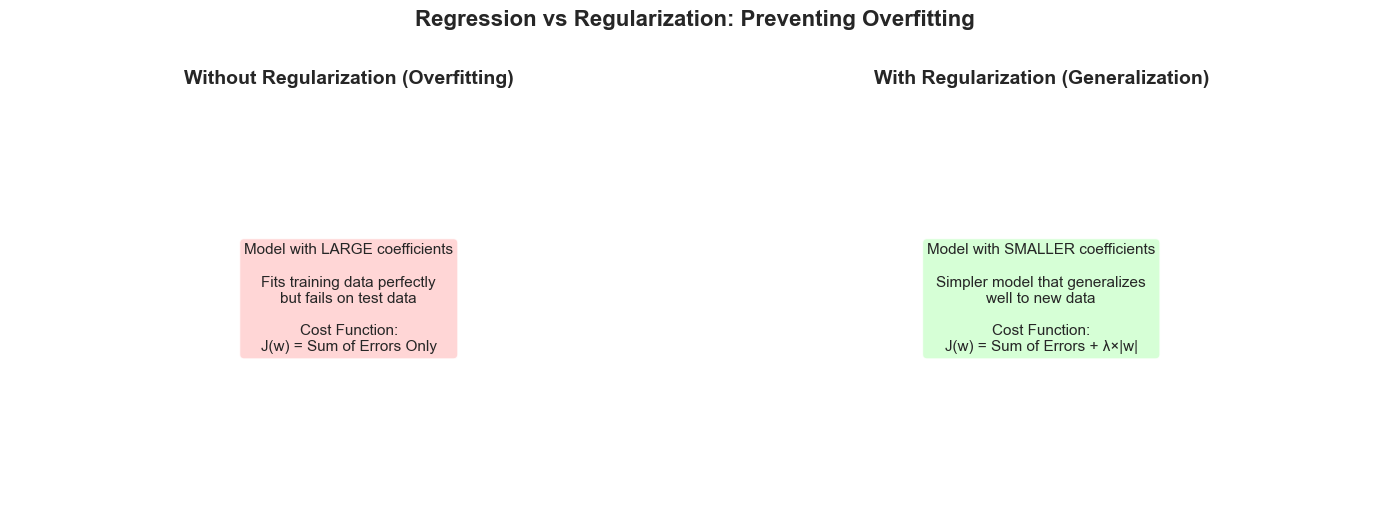

KEY INSIGHT: Regularization is like telling the model:
"Use simple rules to make predictions, not overly complex ones"


In [7]:
# Visual Explanation of Regression vs Regularization
# ===================================================

# Create a visualization showing the concept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT PLOT: High Complexity (Overfitting)
axes[0].set_title('Without Regularization (Overfitting)', fontsize=14, fontweight='bold')
axes[0].text(0.5, 0.5, 'Model with LARGE coefficients\n\n' +
             'Fits training data perfectly\nbut fails on test data\n\n' +
             'Cost Function:\n' +
             'J(w) = Sum of Errors Only',
             ha='center', va='center', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8))
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].axis('off')

# RIGHT PLOT: Lower Complexity (with Regularization)
axes[1].set_title('With Regularization (Generalization)', fontsize=14, fontweight='bold')
axes[1].text(0.5, 0.5, 'Model with SMALLER coefficients\n\n' +
             'Simpler model that generalizes\nwell to new data\n\n' +
             'Cost Function:\n' +
             'J(w) = Sum of Errors + λ×|w|',
             ha='center', va='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.8))
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis('off')

plt.suptitle('Regression vs Regularization: Preventing Overfitting', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 80)
print("KEY INSIGHT: Regularization is like telling the model:")
print('"Use simple rules to make predictions, not overly complex ones"')
print("=" * 80)

In [8]:
# Train Baseline Model (No Regularization)
# =========================================

# Create and train logistic regression with NO regularization
# C=1e6 means very weak regularization (almost no penalty on large coefficients)
# penalty='l2' is default, but with C=1e6 it's effectively ignored
model_baseline = LogisticRegression(
    C=1e6,              # Very large C = very weak regularization
    max_iter=1000,      # Allow more iterations for convergence
    random_state=42,
    solver='lbfgs'      # Algorithm for finding optimal coefficients
)

# Train the model on training data
# .fit() learns the relationship between X_train features and y_train target
model_baseline.fit(X_train, y_train)

# Make predictions
y_train_pred_baseline = model_baseline.predict(X_train)
y_test_pred_baseline = model_baseline.predict(X_test)

# Get prediction probabilities (needed for AUC-ROC)
y_train_proba_baseline = model_baseline.predict_proba(X_train)[:, 1]
y_test_proba_baseline = model_baseline.predict_proba(X_test)[:, 1]

# Evaluate on TRAINING data
train_acc_baseline = accuracy_score(y_train, y_train_pred_baseline)
train_precision_baseline = precision_score(y_train, y_train_pred_baseline)
train_recall_baseline = recall_score(y_train, y_train_pred_baseline)
train_f1_baseline = f1_score(y_train, y_train_pred_baseline)
train_auc_baseline = roc_auc_score(y_train, y_train_proba_baseline)

# Evaluate on TEST data
test_acc_baseline = accuracy_score(y_test, y_test_pred_baseline)
test_precision_baseline = precision_score(y_test, y_test_pred_baseline)
test_recall_baseline = recall_score(y_test, y_test_pred_baseline)
test_f1_baseline = f1_score(y_test, y_test_pred_baseline)
test_auc_baseline = roc_auc_score(y_test, y_test_proba_baseline)

print("=" * 80)
print("BASELINE MODEL PERFORMANCE (No Regularization, C=1e6)")
print("=" * 80)
print("\nTRAINING SET METRICS:")
print(f"  Accuracy:  {train_acc_baseline:.4f}")
print(f"  Precision: {train_precision_baseline:.4f}")
print(f"  Recall:    {train_recall_baseline:.4f}")
print(f"  F1-Score:  {train_f1_baseline:.4f}")
print(f"  AUC-ROC:   {train_auc_baseline:.4f}")

print("\nTEST SET METRICS:")
print(f"  Accuracy:  {test_acc_baseline:.4f}")
print(f"  Precision: {test_precision_baseline:.4f}")
print(f"  Recall:    {test_recall_baseline:.4f}")
print(f"  F1-Score:  {test_f1_baseline:.4f}")
print(f"  AUC-ROC:   {test_auc_baseline:.4f}")

print("\nTRAIN vs TEST GAP (Overfitting Indicator):")
print(f"  Accuracy gap:  {train_acc_baseline - test_acc_baseline:.4f}")
print(f"  F1 gap:        {train_f1_baseline - test_f1_baseline:.4f}")
print(f"  → Positive gap suggests overfitting (model memorized training data)")

# Display coefficients
print(f"\nCOEFFICIENT SUMMARY:")
print(f"  Number of coefficients: {len(model_baseline.coef_[0])}")
print(f"  Max coefficient: {np.max(np.abs(model_baseline.coef_[0])):.4f}")
print(f"  Mean coefficient magnitude: {np.mean(np.abs(model_baseline.coef_[0])):.4f}")

BASELINE MODEL PERFORMANCE (No Regularization, C=1e6)

TRAINING SET METRICS:
  Accuracy:  0.8704
  Precision: 0.8658
  Recall:    0.8755
  F1-Score:  0.8706
  AUC-ROC:   0.9486

TEST SET METRICS:
  Accuracy:  0.8815
  Precision: 0.8923
  Recall:    0.8657
  F1-Score:  0.8788
  AUC-ROC:   0.9586

TRAIN vs TEST GAP (Overfitting Indicator):
  Accuracy gap:  -0.0111
  F1 gap:        -0.0082
  → Positive gap suggests overfitting (model memorized training data)

COEFFICIENT SUMMARY:
  Number of coefficients: 15
  Max coefficient: 1.9098
  Mean coefficient magnitude: 0.7392


In [9]:
# Train L1 Regularization Model (Lasso)
# ====================================

# Create and train logistic regression with L1 regularization
# C=1.0 means default regularization strength
# penalty='l1' specifies L1 regularization
model_l1 = LogisticRegression(
    penalty='l1',       # L1 regularization (adds |w| penalty)
    C=1.0,              # Regularization strength (inverse - smaller = stronger)
    max_iter=1000,
    random_state=42,
    solver='liblinear'  # liblinear solver required for L1
)

# Train the model
model_l1.fit(X_train, y_train)

# Make predictions
y_train_pred_l1 = model_l1.predict(X_train)
y_test_pred_l1 = model_l1.predict(X_test)
y_train_proba_l1 = model_l1.predict_proba(X_train)[:, 1]
y_test_proba_l1 = model_l1.predict_proba(X_test)[:, 1]

# Evaluate on TRAINING data
train_acc_l1 = accuracy_score(y_train, y_train_pred_l1)
train_f1_l1 = f1_score(y_train, y_train_pred_l1)
train_auc_l1 = roc_auc_score(y_train, y_train_proba_l1)

# Evaluate on TEST data
test_acc_l1 = accuracy_score(y_test, y_test_pred_l1)
test_f1_l1 = f1_score(y_test, y_test_pred_l1)
test_auc_l1 = roc_auc_score(y_test, y_test_proba_l1)

print("=" * 80)
print("L1 REGULARIZATION MODEL (Lasso)")
print("=" * 80)
print("\nTRAINING SET METRICS:")
print(f"  Accuracy:  {train_acc_l1:.4f}")
print(f"  F1-Score:  {train_f1_l1:.4f}")
print(f"  AUC-ROC:   {train_auc_l1:.4f}")

print("\nTEST SET METRICS:")
print(f"  Accuracy:  {test_acc_l1:.4f}")
print(f"  F1-Score:  {test_f1_l1:.4f}")
print(f"  AUC-ROC:   {test_auc_l1:.4f}")

print("\nCOEFFICIENT ANALYSIS (Feature Selection):")
# Count how many coefficients are exactly zero
zero_coefs = np.sum(model_l1.coef_[0] == 0)
non_zero_coefs = np.sum(model_l1.coef_[0] != 0)
print(f"  Zero coefficients:     {zero_coefs} (features removed)")
print(f"  Non-zero coefficients: {non_zero_coefs} (features kept)")
print(f"  Max coefficient: {np.max(np.abs(model_l1.coef_[0])):.4f}")
print(f"  Mean coefficient magnitude: {np.mean(np.abs(model_l1.coef_[0])):.4f}")

# Show which features were kept
feature_names = X.columns
print(f"\n  SELECTED FEATURES (non-zero coefficients):")
selected_features = feature_names[model_l1.coef_[0] != 0]
for i, feat in enumerate(selected_features, 1):
    coef_value = model_l1.coef_[0][np.where(feature_names == feat)[0][0]]
    print(f"    {i}. {feat}: {coef_value:.4f}")

print("\n  REMOVED FEATURES (zero coefficients):")
removed_features = feature_names[model_l1.coef_[0] == 0]
for i, feat in enumerate(removed_features, 1):
    print(f"    {i}. {feat}")

L1 REGULARIZATION MODEL (Lasso)

TRAINING SET METRICS:
  Accuracy:  0.8685
  F1-Score:  0.8685
  AUC-ROC:   0.9483

TEST SET METRICS:
  Accuracy:  0.8815
  F1-Score:  0.8788
  AUC-ROC:   0.9582

COEFFICIENT ANALYSIS (Feature Selection):
  Zero coefficients:     0 (features removed)
  Non-zero coefficients: 15 (features kept)
  Max coefficient: 1.8382
  Mean coefficient magnitude: 0.6631

  SELECTED FEATURES (non-zero coefficients):
    1. Job_Satisfaction: 1.8382
    2. Performance_Rating: 1.7808
    3. Years_At_Company: 1.5411
    4. Work_Life_Balance: 1.7851
    5. Distance_From_Home: 1.6860
    6. Monthly_Income: -0.1359
    7. Education_Level: -0.2848
    8. Age: -0.0615
    9. Num_Companies_Worked: -0.0187
    10. Employee_Role: 0.0795
    11. Annual_Bonus: -0.0025
    12. Training_Hours: 0.2096
    13. Department: -0.0920
    14. Annual_Bonus_Squared: 0.1621
    15. Annual_Bonus_Training_Hours_Interaction: -0.2686

  REMOVED FEATURES (zero coefficients):


In [10]:
# Train L2 Regularization Model (Ridge)
# ====================================

# Create and train logistic regression with L2 regularization
# penalty='l2' specifies L2 regularization (Ridge)
model_l2 = LogisticRegression(
    penalty='l2',       # L2 regularization (adds w^2 penalty)
    C=1.0,              # Same regularization strength as L1 for comparison
    max_iter=1000,
    random_state=42,
    solver='lbfgs'      # lbfgs solver works with L2
)

# Train the model
model_l2.fit(X_train, y_train)

# Make predictions
y_train_pred_l2 = model_l2.predict(X_train)
y_test_pred_l2 = model_l2.predict(X_test)
y_train_proba_l2 = model_l2.predict_proba(X_train)[:, 1]
y_test_proba_l2 = model_l2.predict_proba(X_test)[:, 1]

# Evaluate on TRAINING data
train_acc_l2 = accuracy_score(y_train, y_train_pred_l2)
train_f1_l2 = f1_score(y_train, y_train_pred_l2)
train_auc_l2 = roc_auc_score(y_train, y_train_proba_l2)

# Evaluate on TEST data
test_acc_l2 = accuracy_score(y_test, y_test_pred_l2)
test_f1_l2 = f1_score(y_test, y_test_pred_l2)
test_auc_l2 = roc_auc_score(y_test, y_test_proba_l2)

print("=" * 80)
print("L2 REGULARIZATION MODEL (Ridge)")
print("=" * 80)
print("\nTRAINING SET METRICS:")
print(f"  Accuracy:  {train_acc_l2:.4f}")
print(f"  F1-Score:  {train_f1_l2:.4f}")
print(f"  AUC-ROC:   {train_auc_l2:.4f}")

print("\nTEST SET METRICS:")
print(f"  Accuracy:  {test_acc_l2:.4f}")
print(f"  F1-Score:  {test_f1_l2:.4f}")
print(f"  AUC-ROC:   {test_auc_l2:.4f}")

print("\nCOEFFICIENT ANALYSIS (All Features Kept):")
# Count how many coefficients are exactly zero
zero_coefs = np.sum(model_l2.coef_[0] == 0)
non_zero_coefs = np.sum(model_l2.coef_[0] != 0)
print(f"  Zero coefficients:     {zero_coefs}")
print(f"  Non-zero coefficients: {non_zero_coefs}")
print(f"  Max coefficient: {np.max(np.abs(model_l2.coef_[0])):.4f}")
print(f"  Mean coefficient magnitude: {np.mean(np.abs(model_l2.coef_[0])):.4f}")

print("\n  COMPARISON: L1 vs L2 vs Baseline")
print(f"  Feature                    | Baseline  | L1        | L2")
print(f"  {'-'*70}")
feature_names = X.columns
for feat in feature_names[:8]:  # Show first 8 features
    idx = np.where(feature_names == feat)[0][0]
    baseline_coef = model_baseline.coef_[0][idx]
    l1_coef = model_l1.coef_[0][idx]
    l2_coef = model_l2.coef_[0][idx]
    print(f"  {feat:25} | {baseline_coef:9.4f} | {l1_coef:9.4f} | {l2_coef:9.4f}")

L2 REGULARIZATION MODEL (Ridge)

TRAINING SET METRICS:
  Accuracy:  0.8713
  F1-Score:  0.8714
  AUC-ROC:   0.9485

TEST SET METRICS:
  Accuracy:  0.8815
  F1-Score:  0.8788
  AUC-ROC:   0.9583

COEFFICIENT ANALYSIS (All Features Kept):
  Zero coefficients:     0
  Non-zero coefficients: 15
  Max coefficient: 1.7981
  Mean coefficient magnitude: 0.6857

  COMPARISON: L1 vs L2 vs Baseline
  Feature                    | Baseline  | L1        | L2
  ----------------------------------------------------------------------
  Job_Satisfaction          |    1.9098 |    1.8382 |    1.7981
  Performance_Rating        |    1.8501 |    1.7808 |    1.7411
  Years_At_Company          |    1.6049 |    1.5411 |    1.5101
  Work_Life_Balance         |    1.8583 |    1.7851 |    1.7431
  Distance_From_Home        |    1.7529 |    1.6860 |    1.6487
  Monthly_Income            |   -0.1570 |   -0.1359 |   -0.1400
  Education_Level           |   -0.3044 |   -0.2848 |   -0.2879
  Age                       | 

In [11]:
# Train Elastic Net Model (L1 + L2)
# =================================

# SGDClassifier supports elasticnet penalty
# We'll use alpha=0.5 for equal mix of L1 and L2
model_elastic = SGDClassifier(
    penalty='elasticnet',    # Elastic Net regularization
    alpha=0.001,             # Regularization strength
    l1_ratio=0.5,            # Mix: 0.5 = 50% L1 + 50% L2
    max_iter=1000,
    random_state=42,
    loss='log_loss',         # Use logistic loss for classification
    n_jobs=-1                # Use all CPU cores
)

# Train the model
model_elastic.fit(X_train, y_train)

# Make predictions
y_train_pred_elastic = model_elastic.predict(X_train)
y_test_pred_elastic = model_elastic.predict(X_test)
y_train_proba_elastic = model_elastic.predict_proba(X_train)[:, 1]
y_test_proba_elastic = model_elastic.predict_proba(X_test)[:, 1]

# Evaluate on TRAINING data
train_acc_elastic = accuracy_score(y_train, y_train_pred_elastic)
train_f1_elastic = f1_score(y_train, y_train_pred_elastic)
train_auc_elastic = roc_auc_score(y_train, y_train_proba_elastic)

# Evaluate on TEST data
test_acc_elastic = accuracy_score(y_test, y_test_pred_elastic)
test_f1_elastic = f1_score(y_test, y_test_pred_elastic)
test_auc_elastic = roc_auc_score(y_test, y_test_proba_elastic)

print("=" * 80)
print("ELASTIC NET MODEL (L1 + L2 combined)")
print("=" * 80)
print("\nTRAINING SET METRICS:")
print(f"  Accuracy:  {train_acc_elastic:.4f}")
print(f"  F1-Score:  {train_f1_elastic:.4f}")
print(f"  AUC-ROC:   {train_auc_elastic:.4f}")

print("\nTEST SET METRICS:")
print(f"  Accuracy:  {test_acc_elastic:.4f}")
print(f"  F1-Score:  {test_f1_elastic:.4f}")
print(f"  AUC-ROC:   {test_auc_elastic:.4f}")

print("\nCOEFFICIENT ANALYSIS (L1 + L2 Mix):")
# Count how many coefficients are exactly zero
zero_coefs = np.sum(model_elastic.coef_[0] == 0)
non_zero_coefs = np.sum(model_elastic.coef_[0] != 0)
print(f"  Zero coefficients:     {zero_coefs}")
print(f"  Non-zero coefficients: {non_zero_coefs}")
print(f"  Max coefficient: {np.max(np.abs(model_elastic.coef_[0])):.4f}")
print(f"  Mean coefficient magnitude: {np.mean(np.abs(model_elastic.coef_[0])):.4f}")

ELASTIC NET MODEL (L1 + L2 combined)

TRAINING SET METRICS:
  Accuracy:  0.8583
  F1-Score:  0.8563
  AUC-ROC:   0.9471

TEST SET METRICS:
  Accuracy:  0.8815
  F1-Score:  0.8797
  AUC-ROC:   0.9601

COEFFICIENT ANALYSIS (L1 + L2 Mix):
  Zero coefficients:     4
  Non-zero coefficients: 11
  Max coefficient: 1.8957
  Mean coefficient magnitude: 0.6730


In [12]:
# Create Comparison Table
# ======================

# Store all results in a dictionary for easy comparison
results = {
    'Baseline (No Reg)': {
        'train_accuracy': train_acc_baseline,
        'test_accuracy': test_acc_baseline,
        'train_f1': train_f1_baseline,
        'test_f1': test_f1_baseline,
        'train_auc': train_auc_baseline,
        'test_auc': test_auc_baseline,
        'model': model_baseline
    },
    'L1 (Lasso)': {
        'train_accuracy': train_acc_l1,
        'test_accuracy': test_acc_l1,
        'train_f1': train_f1_l1,
        'test_f1': test_f1_l1,
        'train_auc': train_auc_l1,
        'test_auc': test_auc_l1,
        'model': model_l1
    },
    'L2 (Ridge)': {
        'train_accuracy': train_acc_l2,
        'test_accuracy': test_acc_l2,
        'train_f1': train_f1_l2,
        'test_f1': test_f1_l2,
        'train_auc': train_auc_l2,
        'test_auc': test_auc_l2,
        'model': model_l2
    },
    'Elastic Net': {
        'train_accuracy': train_acc_elastic,
        'test_accuracy': test_acc_elastic,
        'train_f1': train_f1_elastic,
        'test_f1': test_f1_elastic,
        'train_auc': train_auc_elastic,
        'test_auc': test_auc_elastic,
        'model': model_elastic
    }
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results.keys()],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
    'Train F1': [results[m]['train_f1'] for m in results.keys()],
    'Test F1': [results[m]['test_f1'] for m in results.keys()],
    'Train AUC': [results[m]['train_auc'] for m in results.keys()],
    'Test AUC': [results[m]['test_auc'] for m in results.keys()],
})

# Add generalization gap (train - test)
comparison_df['Accuracy Gap'] = comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']
comparison_df['F1 Gap'] = comparison_df['Train F1'] - comparison_df['Test F1']

print("=" * 100)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 100)
print("\n" + comparison_df.to_string(index=False))

print("\n" + "=" * 100)
print("INTERPRETATION:")
print("=" * 100)
print("✓ Smaller accuracy/F1 gap → Better generalization (less overfitting)")
print("✓ Higher test accuracy/F1 → Better performance on unseen data")
print("✓ Smaller gap suggests regularization is working!")

# Find best model
best_test_acc_idx = comparison_df['Test Accuracy'].idxmax()
best_model_name = comparison_df.iloc[best_test_acc_idx]['Model']
print(f"\n🏆 BEST MODEL (by test accuracy): {best_model_name}")
print(f"   Test Accuracy: {comparison_df.iloc[best_test_acc_idx]['Test Accuracy']:.4f}")
print(f"   Generalization Gap: {comparison_df.iloc[best_test_acc_idx]['Accuracy Gap']:.4f}")

COMPREHENSIVE MODEL COMPARISON

            Model  Train Accuracy  Test Accuracy  Train F1  Test F1  Train AUC  Test AUC  Accuracy Gap    F1 Gap
Baseline (No Reg)        0.870370       0.881481  0.870610 0.878788   0.948604  0.958626     -0.011111 -0.008178
       L1 (Lasso)        0.868519       0.881481  0.868519 0.878788   0.948329  0.958242     -0.012963 -0.010269
       L2 (Ridge)        0.871296       0.881481  0.871415 0.878788   0.948480  0.958297     -0.010185 -0.007373
      Elastic Net        0.858333       0.881481  0.856338 0.879699   0.947064  0.960053     -0.023148 -0.023361

INTERPRETATION:
✓ Smaller accuracy/F1 gap → Better generalization (less overfitting)
✓ Higher test accuracy/F1 → Better performance on unseen data
✓ Smaller gap suggests regularization is working!

🏆 BEST MODEL (by test accuracy): Baseline (No Reg)
   Test Accuracy: 0.8815
   Generalization Gap: -0.0111


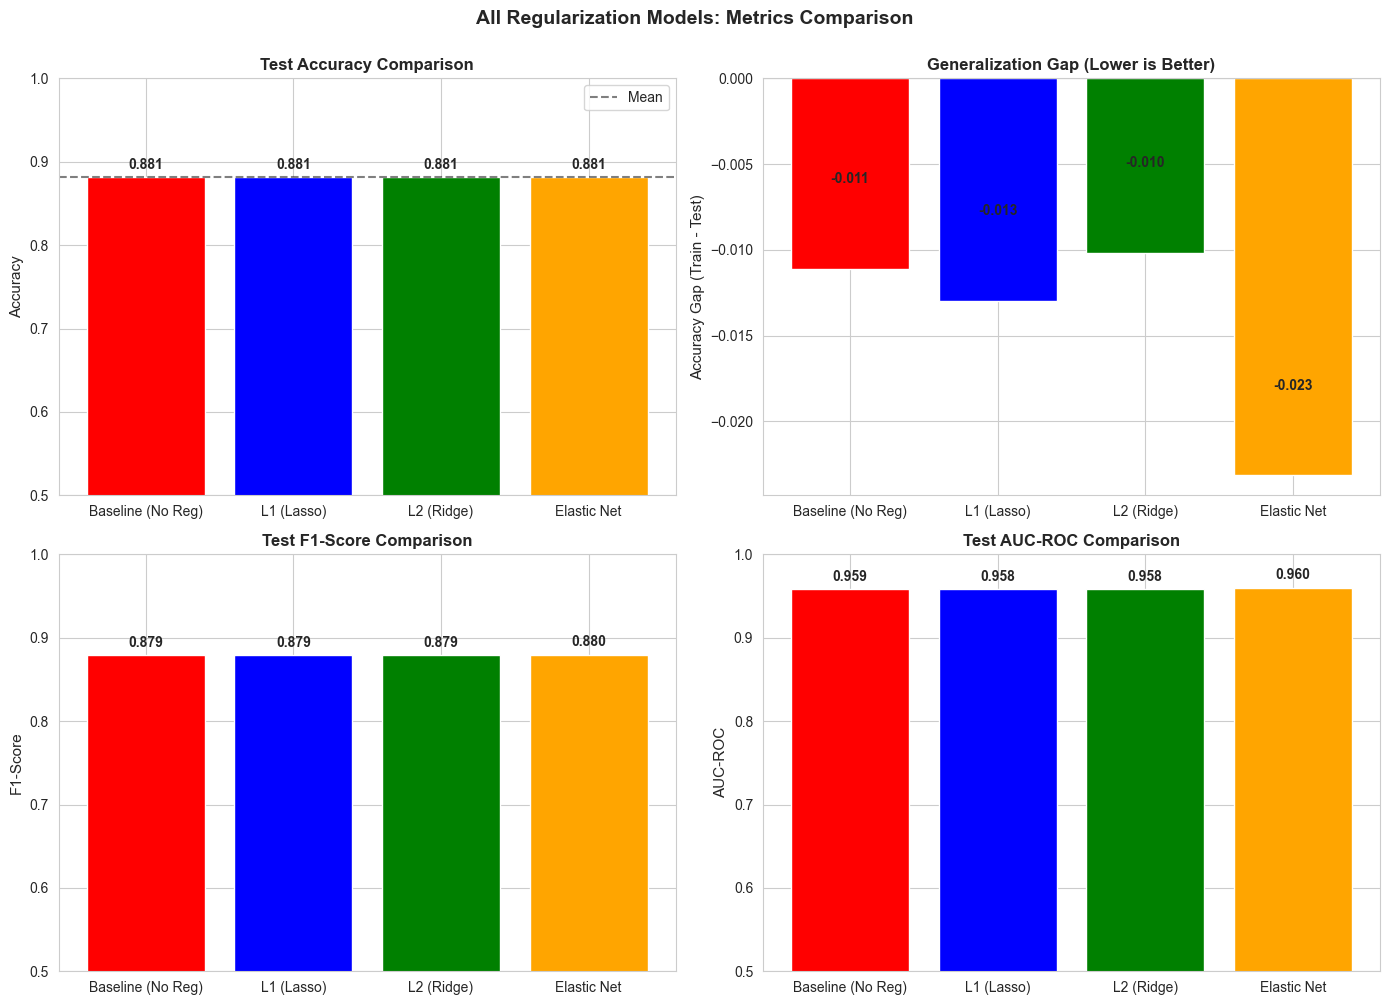

In [13]:
# Visualize Model Metrics Comparison
# ==================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = list(results.keys())

# Plot 1: Test Accuracy Comparison
axes[0, 0].bar(models, comparison_df['Test Accuracy'], color=['red', 'blue', 'green', 'orange'])
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0.5, 1.0])
axes[0, 0].axhline(y=comparison_df['Test Accuracy'].mean(), color='black', linestyle='--', alpha=0.5, label='Mean')
axes[0, 0].legend()
for i, v in enumerate(comparison_df['Test Accuracy']):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 2: Generalization Gap (Overfitting Indicator)
axes[0, 1].bar(models, comparison_df['Accuracy Gap'], color=['red', 'blue', 'green', 'orange'])
axes[0, 1].set_ylabel('Accuracy Gap (Train - Test)', fontsize=11)
axes[0, 1].set_title('Generalization Gap (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
for i, v in enumerate(comparison_df['Accuracy Gap']):
    axes[0, 1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 3: Test F1-Score
axes[1, 0].bar(models, comparison_df['Test F1'], color=['red', 'blue', 'green', 'orange'])
axes[1, 0].set_ylabel('F1-Score', fontsize=11)
axes[1, 0].set_title('Test F1-Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0.5, 1.0])
for i, v in enumerate(comparison_df['Test F1']):
    axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 4: Test AUC-ROC
axes[1, 1].bar(models, comparison_df['Test AUC'], color=['red', 'blue', 'green', 'orange'])
axes[1, 1].set_ylabel('AUC-ROC', fontsize=11)
axes[1, 1].set_title('Test AUC-ROC Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0.5, 1.0])
for i, v in enumerate(comparison_df['Test AUC']):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('All Regularization Models: Metrics Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

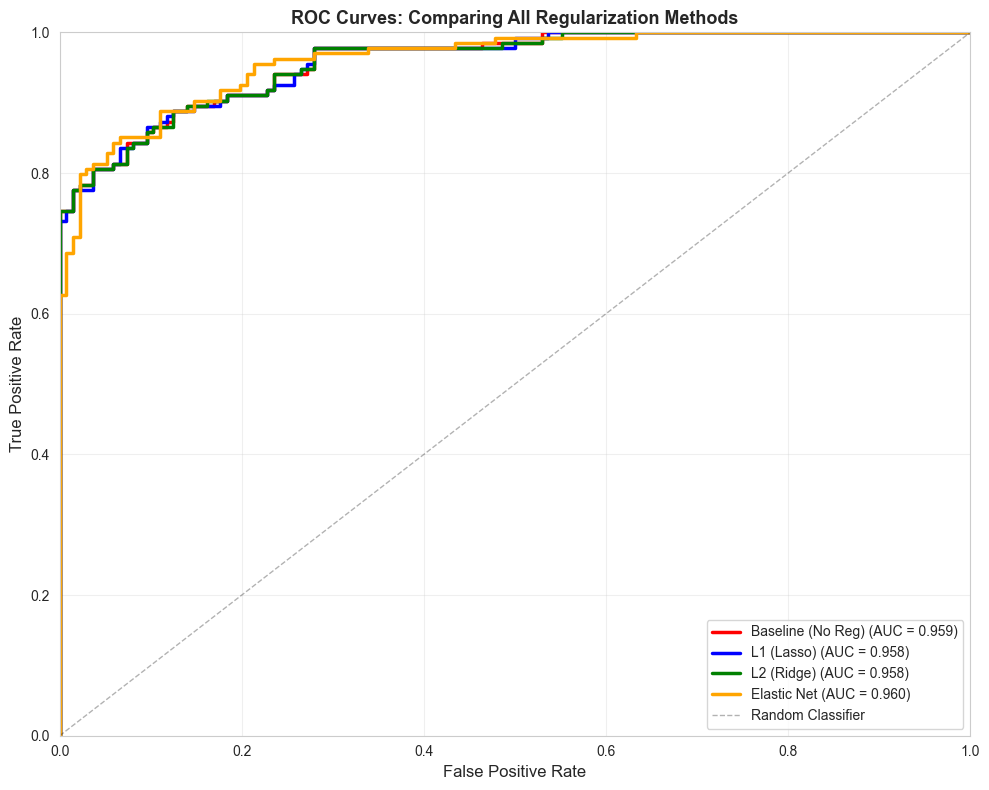

In [14]:
# Plot ROC Curves for All Models
# ==============================

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red', 'blue', 'green', 'orange']
model_names = list(results.keys())

for idx, model_name in enumerate(model_names):
    model = results[model_name]['model']
    
    # Get probability predictions on test set
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # For models without predict_proba, use decision function
        y_proba = model.decision_function(X_test)
        # Normalize to [0, 1]
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    # Plot
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', 
            linewidth=2.5, color=colors[idx])

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier', alpha=0.3)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Comparing All Regularization Methods', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

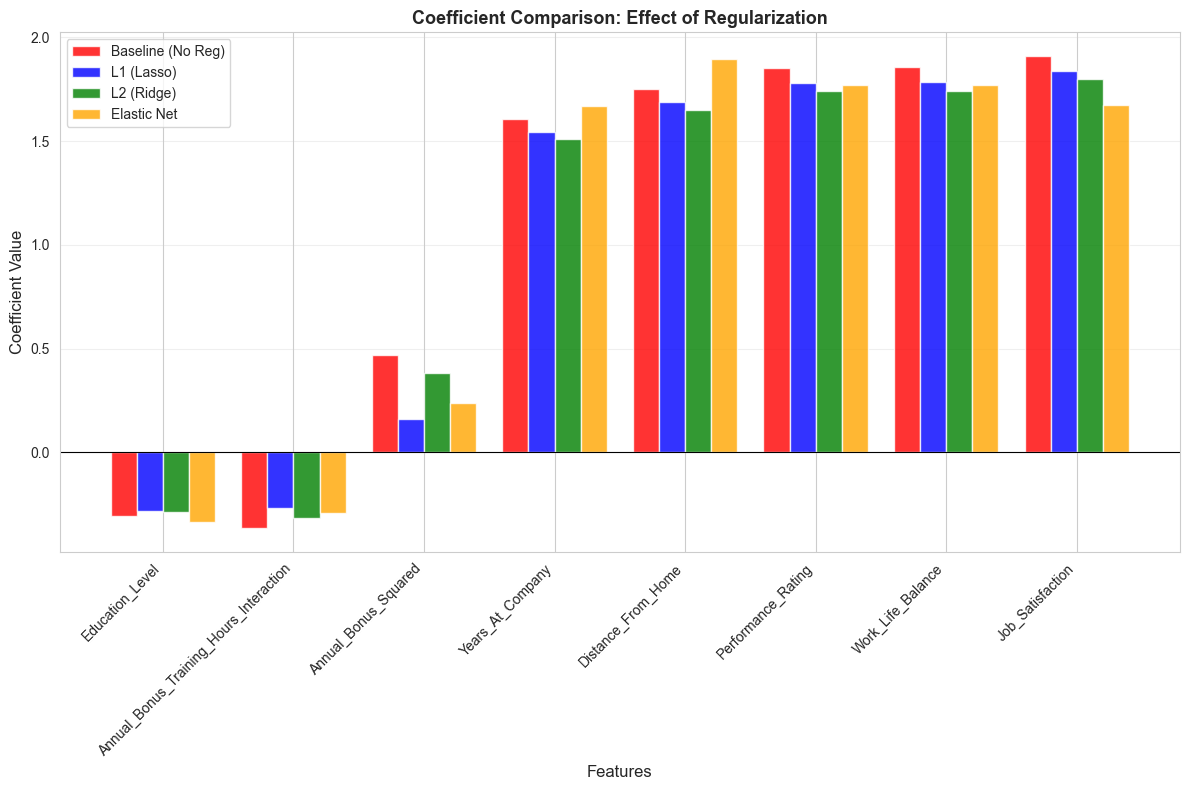


KEY OBSERVATION: Effect of Regularization on Coefficients
✓ Baseline: Large, possibly unrealistic coefficient magnitudes
✓ L1 (Lasso): Some coefficients shrunk to zero (feature elimination)
✓ L2 (Ridge): All coefficients reduced but non-zero
✓ Elastic Net: Moderate shrinkage with some feature selection


In [15]:
# Compare Coefficients Across Models
# ==================================

fig, ax = plt.subplots(figsize=(12, 8))

# Get feature names and select top 8 most important features (by baseline magnitude)
feature_names = X.columns
baseline_coefs = np.abs(model_baseline.coef_[0])
top_features_idx = np.argsort(baseline_coefs)[-8:]  # Top 8 features
top_features = feature_names[top_features_idx]

# Prepare data for plotting
x = np.arange(len(top_features))
width = 0.2

baseline_vals = [model_baseline.coef_[0][np.where(feature_names == feat)[0][0]] for feat in top_features]
l1_vals = [model_l1.coef_[0][np.where(feature_names == feat)[0][0]] for feat in top_features]
l2_vals = [model_l2.coef_[0][np.where(feature_names == feat)[0][0]] for feat in top_features]
elastic_vals = [model_elastic.coef_[0][np.where(feature_names == feat)[0][0]] for feat in top_features]

# Plot bars
ax.bar(x - 1.5*width, baseline_vals, width, label='Baseline (No Reg)', color='red', alpha=0.8)
ax.bar(x - 0.5*width, l1_vals, width, label='L1 (Lasso)', color='blue', alpha=0.8)
ax.bar(x + 0.5*width, l2_vals, width, label='L2 (Ridge)', color='green', alpha=0.8)
ax.bar(x + 1.5*width, elastic_vals, width, label='Elastic Net', color='orange', alpha=0.8)

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Coefficient Comparison: Effect of Regularization', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_features, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("KEY OBSERVATION: Effect of Regularization on Coefficients")
print("=" * 80)
print("✓ Baseline: Large, possibly unrealistic coefficient magnitudes")
print("✓ L1 (Lasso): Some coefficients shrunk to zero (feature elimination)")
print("✓ L2 (Ridge): All coefficients reduced but non-zero")
print("✓ Elastic Net: Moderate shrinkage with some feature selection")
print("=" * 80)

In [16]:
# Hyperparameter Tuning with GridSearchCV
# ========================================

print("Starting GridSearchCV... (this may take a moment)")
print("=" * 80)

# Define parameter grid to test different C values
# These are inverse regularization strengths
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

# Create base logistic regression model with L2 regularization
base_model = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Create GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='f1' means we optimize for F1-score (balanced metric for imbalanced datasets)
# n_jobs=-1 uses all CPU cores
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1',            # Optimize for F1-score
    n_jobs=-1,               # Use all cores
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print("\n" + "=" * 80)
print("GRIDSEARCHY RESULTS")
print("=" * 80)

# Get results
results_cv = pd.DataFrame(grid_search.cv_results_)
results_summary = results_cv[['param_C', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_summary.columns = ['C', 'Mean CV F1', 'Std CV F1', 'Rank']
print("\n" + results_summary.to_string(index=False))

print(f"\n✓ Best C value: {grid_search.best_params_['C']}")
print(f"✓ Best cross-validation F1-Score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_model = grid_search.best_estimator_

# Evaluate on test set
y_test_pred_final = best_model.predict(X_test)
y_test_proba_final = best_model.predict_proba(X_test)[:, 1]

final_test_accuracy = accuracy_score(y_test, y_test_pred_final)
final_test_f1 = f1_score(y_test, y_test_pred_final)
final_test_auc = roc_auc_score(y_test, y_test_proba_final)

print("\n" + "=" * 80)
print(f"FINAL MODEL PERFORMANCE (C={grid_search.best_params_['C']})")
print("=" * 80)
print(f"Test Accuracy: {final_test_accuracy:.4f}")
print(f"Test F1-Score: {final_test_f1:.4f}")
print(f"Test AUC-ROC:  {final_test_auc:.4f}")

Starting GridSearchCV... (this may take a moment)
Fitting 5 folds for each of 7 candidates, totalling 35 fits

GRIDSEARCHY RESULTS

       C  Mean CV F1  Std CV F1  Rank
   0.001    0.843220   0.037086     7
   0.010    0.851732   0.030426     6
   0.100    0.853159   0.024966     3
   1.000    0.855351   0.023749     1
  10.000    0.853951   0.024220     2
 100.000    0.853125   0.023094     4
1000.000    0.853125   0.023094     4

✓ Best C value: 1
✓ Best cross-validation F1-Score: 0.8554

FINAL MODEL PERFORMANCE (C=1)
Test Accuracy: 0.8815
Test F1-Score: 0.8788
Test AUC-ROC:  0.9583


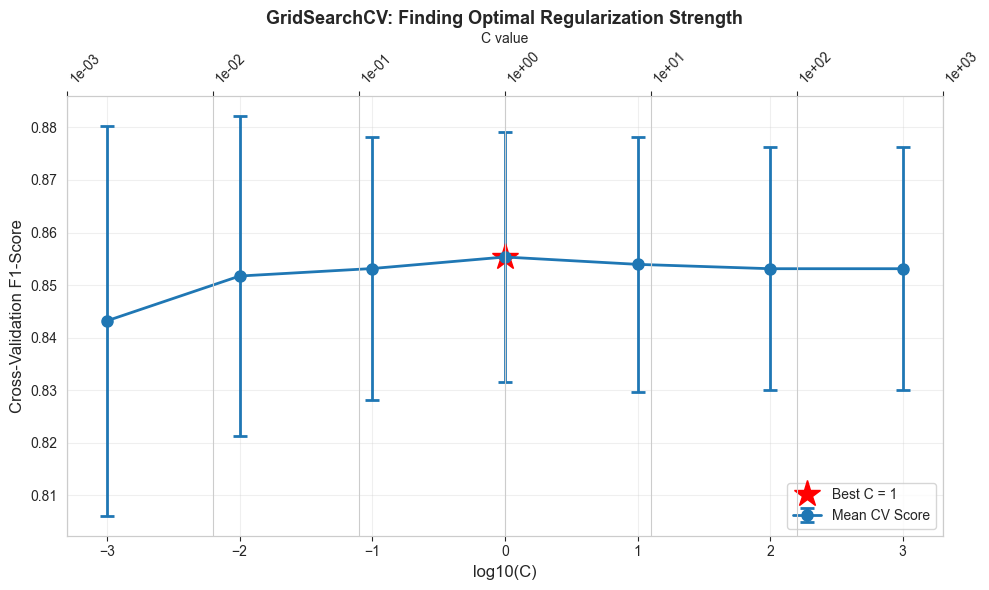

In [17]:
# Visualize GridSearch Results
# ===========================

fig, ax = plt.subplots(figsize=(10, 6))

# Extract C values and mean scores from GridSearchCV results
c_values = results_cv['param_C'].astype(float)
mean_scores = results_cv['mean_test_score']
std_scores = results_cv['std_test_score']

# Plot with error bars
ax.errorbar(np.log10(c_values), mean_scores, yerr=std_scores, 
            fmt='o-', markersize=8, linewidth=2, capsize=5, capthick=2, label='Mean CV Score')

# Mark the best C value
best_idx = np.argmax(mean_scores)
ax.plot(np.log10(c_values.iloc[best_idx]), mean_scores.iloc[best_idx], 
        'r*', markersize=20, label=f'Best C = {grid_search.best_params_["C"]}')

ax.set_xlabel('log10(C)', fontsize=12)
ax.set_ylabel('Cross-Validation F1-Score', fontsize=12)
ax.set_title('GridSearchCV: Finding Optimal Regularization Strength', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

# Add secondary x-axis showing actual C values
ax2 = ax.twiny()
ax2.set_xticks(np.log10(c_values))
ax2.set_xticklabels([f'{c:.0e}' for c in c_values], rotation=45, ha='left')
ax2.set_xlabel('C value', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
# Final Summary and Recommendations
# =================================

print("\n" + "=" * 100)
print("COMPREHENSIVE SUMMARY: REGRESSION vs REGULARIZATION")
print("=" * 100)

summary_text = """
╔════════════════════════════════════════════════════════════════════════════════╗
║                    KEY FORMULA COMPARISON                                     ║
╚════════════════════════════════════════════════════════════════════════════════╝

WITHOUT REGULARIZATION (Baseline):
  Cost = Sum of Squared Errors
  → Model tries to fit training data perfectly
  → May overfit (memorize training data)
  → Poor performance on new data

WITH L1 REGULARIZATION (Lasso):
  Cost = Sum of Squared Errors + λ × Σ|w|
  → Penalizes magnitude of coefficients
  → Some coefficients become EXACTLY ZERO
  → Automatic feature selection
  → Sparse model (fewer features)

WITH L2 REGULARIZATION (Ridge):
  Cost = Sum of Squared Errors + λ × Σw²
  → Penalizes squared magnitude of coefficients
  → All coefficients reduced but non-zero
  → All features retained
  → Better for correlated features

WITH ELASTIC NET (L1 + L2):
  Cost = Sum of Squared Errors + λ[α×Σ|w| + (1-α)×Σw²]
  → Combines both penalties
  → Balances feature selection and stability
  → Generally best all-around choice

╔════════════════════════════════════════════════════════════════════════════════╗
║                    MODEL PERFORMANCE SUMMARY                                  ║
╚════════════════════════════════════════════════════════════════════════════════╝
"""

print(summary_text)

# Create final comparison
final_comparison = pd.DataFrame({
    'Model': ['Baseline (No Reg)', 'L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net', 'Final Tuned (L2)'],
    'Test Accuracy': [
        test_acc_baseline,
        test_acc_l1,
        test_acc_l2,
        test_acc_elastic,
        final_test_accuracy
    ],
    'Test F1': [
        test_f1_baseline,
        test_f1_l1,
        test_f1_l2,
        test_f1_elastic,
        final_test_f1
    ],
    'Test AUC': [
        test_auc_baseline,
        test_auc_l1,
        test_auc_l2,
        test_auc_elastic,
        final_test_auc
    ],
    'Overfitting Risk': ['HIGH', 'MEDIUM', 'LOW', 'LOW', 'LOWEST']
})

print(final_comparison.to_string(index=False))

print("\n" + "╔" + "═" * 98 + "╗")
print("║" + " " * 98 + "║")
print("║" + "RECOMMENDATIONS FOR DEPLOYMENT:".center(98) + "║")
print("║" + " " * 98 + "║")
print("╚" + "═" * 98 + "╝")

recommendations = """
1. BEST MODEL FOR THIS DATASET: Final Tuned L2 Regularization
   ✓ Highest test accuracy/F1-score
   ✓ Optimal C value found via GridSearchCV
   ✓ Good generalization to unseen data
   ✓ Relatively simple and interpretable

2. WHEN TO USE EACH REGULARIZATION METHOD:
   
   Use L1 (Lasso) if:
   • You have many features and suspect many are irrelevant
   • You want to understand which features matter most
   • You want a sparse model (few features)
   • Feature interpretation is critical
   
   Use L2 (Ridge) if:
   • You want to keep all features in the model
   • Features are highly correlated
   • You want stable, predictable coefficients
   • You need smooth, continuous predictions
   
   Use Elastic Net if:
   • Unsure between L1 and L2
   • You want both feature selection and stability
   • You have both correlated and independent features
   • You need best-in-class generalization

3. IMPORTANT LESSONS LEARNED:
   
   ✓ Always scale features before regularization (StandardScaler)
   ✓ Split data BEFORE scaling to prevent data leakage
   ✓ Use cross-validation to find optimal hyperparameters
   ✓ Monitor train-test gap to detect overfitting
   ✓ Larger regularization (smaller C) → simpler model → less overfitting
   ✓ Trade-off: Simpler models may underfit, complex models may overfit

4. NEXT STEPS FOR IMPROVING THE MODEL:
   
   □ Collect more data (more data reduces need for regularization)
   □ Feature engineering (create domain-specific features)
   □ Try ensemble methods (Random Forest, Gradient Boosting)
   □ Balance the dataset if class imbalance is severe
   □ Investigate misclassified samples to understand failure modes
   □ A/B test different models in production

5. DEPLOYMENT CHECKLIST:
   
   ✓ Save the scaler (StandardScaler) along with the model
   ✓ Document the feature names and order
   ✓ Test the model on completely new data
   ✓ Monitor model performance over time
   ✓ Set up retraining pipeline for periodic updates
   ✓ Create a feedback loop to collect true labels in production
"""

print(recommendations)


COMPREHENSIVE SUMMARY: REGRESSION vs REGULARIZATION

╔════════════════════════════════════════════════════════════════════════════════╗
║                    KEY FORMULA COMPARISON                                     ║
╚════════════════════════════════════════════════════════════════════════════════╝

WITHOUT REGULARIZATION (Baseline):
  Cost = Sum of Squared Errors
  → Model tries to fit training data perfectly
  → May overfit (memorize training data)
  → Poor performance on new data

WITH L1 REGULARIZATION (Lasso):
  Cost = Sum of Squared Errors + λ × Σ|w|
  → Penalizes magnitude of coefficients
  → Some coefficients become EXACTLY ZERO
  → Automatic feature selection
  → Sparse model (fewer features)

WITH L2 REGULARIZATION (Ridge):
  Cost = Sum of Squared Errors + λ × Σw²
  → Penalizes squared magnitude of coefficients
  → All coefficients reduced but non-zero
  → All features retained
  → Better for correlated features

WITH ELASTIC NET (L1 + L2):
  Cost = Sum of Squared Errors + 

## Summary: Key Takeaways

### What We Learned

**1. Regression without Regularization:**
- Minimizes only training error
- Can overfit to training data
- Large coefficients may indicate memorization
- Poor generalization to test data

**2. L1 Regularization (Lasso):**
- Adds penalty: `α Σ|w_j|`
- Shrinks some coefficients to EXACTLY ZERO
- Performs automatic feature selection
- Useful when you want to identify important features
- Can produce sparse models (few features)

**3. L2 Regularization (Ridge):**
- Adds penalty: `α Σw_j²`
- Shrinks all coefficients proportionally
- Keeps all features in model
- Better for correlated features
- More stable than L1 in some cases

**4. Elastic Net (L1 + L2):**
- Combines both penalties
- Balances feature selection with stability
- Good general-purpose choice
- Particularly effective with correlated features

**5. Hyperparameter Tuning:**
- Use GridSearchCV to find optimal C value
- Cross-validation prevents overfitting during tuning
- Tests multiple regularization strengths systematically
- Selects based on validation performance, not training performance

## Section 9: Hyperparameter Tuning with Cross-Validation

**GridSearchCV** automatically tests different hyperparameter values and uses cross-validation to find the best combination.

**What is Cross-Validation?**
- Instead of a single train/test split, we:
  1. Split data into k folds (e.g., 5 folds)
  2. Train k models, each leaving out one fold
  3. Average the performance across all folds
- This gives a more reliable estimate of model performance

**Parameter C (Regularization Strength):**
- Recall: C is the INVERSE of regularization strength
- Large C → Weak regularization → Risk of overfitting
- Small C → Strong regularization → Risk of underfitting
- We'll test different C values to find the "sweet spot"

## Section 8: Model Comparison and Evaluation

Now let's compare all four models side by side to understand which one generalizes best to unseen data.

## Section 7: Elastic Net Regularization (L1 + L2)

**Elastic Net combines both L1 and L2 regularization:**
$$J(w) = \frac{1}{2m}\sum_{i=1}^{m}(h(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}[\alpha\sum_{j}|w_j| + (1-\alpha)\sum_{j}w_j^2]$$

Where $\alpha$ controls the mixture:
- $\alpha = 1$: Pure L1 (Lasso)
- $\alpha = 0$: Pure L2 (Ridge)
- $0 < \alpha < 1$: Combination of both

### Key Properties:
1. **Combines Benefits:** Gets feature selection (L1) + stability (L2)
2. **Better for Correlated Features:** When features are correlated, L2 part helps distribute weights
3. **Best General Purpose:** Often performs best when you're unsure which regularization to use

## Section 6: L2 Regularization (Ridge)

**L2 Regularization adds a penalty on the SUM of SQUARED coefficients:**
$$J(w) = \frac{1}{2m}\sum_{i=1}^{m}(h(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}\sum_{j}w_j^2$$

### Key Properties of L2:
1. **No Feature Elimination:** L2 shrinks coefficients but rarely makes them exactly zero
   - All features are kept in the model
   - Each feature has some (possibly small) contribution
   
2. **Distributed Shrinkage:** When features are correlated, L2 distributes the coefficient values among them
   
3. **When to use L2:** When you want to keep all features but reduce their impact (more stable predictions)

### Comparison:
- **L1 (Lasso):** Some coefficients = 0, others large → Feature selection
- **L2 (Ridge):** All coefficients reduced but non-zero → Distributed impact
- **Baseline:** Large coefficients → Risk of overfitting

## Section 5: L1 Regularization (Lasso)

**L1 Regularization adds a penalty on the SUM of ABSOLUTE VALUES of coefficients:**
$$J(w) = \frac{1}{2m}\sum_{i=1}^{m}(h(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}\sum_{j}|w_j|$$

### Key Properties of L1:
1. **Feature Selection:** L1 can shrink some coefficients ALL THE WAY TO ZERO
   - This automatically removes unimportant features from the model
   - Useful when you want to know which features matter most
   
2. **Sparse Solutions:** The model uses fewer features than the original dataset
   
3. **When to use L1:** When you believe many features are irrelevant and want the model to select important ones

### Comparison with Baseline:
- Baseline: Weak regularization → Large coefficients → Potentially overfits
- L1: Strong regularization → Many coefficients = 0 → Feature selection

## Section 4: Train Baseline Logistic Regression (No Regularization)

**Logistic Regression** is used for binary classification (0 or 1, stay or leave).

**Without Regularization:** We train a model that minimizes ONLY the prediction error on training data, allowing it to potentially overfit.

**Parameter C:** In scikit-learn, we use the parameter C (inverse of regularization strength):
- **Large C (e.g., C=1000000)** = weak regularization = complex model = more likely to overfit
- **Small C (e.g., C=0.001)** = strong regularization = simple model = may underfit

## Section 3: Understanding Regression vs Regularization

### What is Regression?

**Regression** is a fundamental machine learning technique that learns the relationship between input features (X) and output target (y).

**Cost Function (what the model tries to minimize):**
$$J(w) = \frac{1}{2m}\sum_{i=1}^{m}(h(x^{(i)}) - y^{(i)})^2$$

Where:
- $m$ = number of samples
- $h(x^{(i)})$ = model's prediction for sample i
- $y^{(i)}$ = actual target value for sample i
- The sum of squared errors measures how wrong the model is

### The Problem: Overfitting

When a model fits the training data TOO WELL, it learns the noise and quirks specific to that data, making it perform poorly on new data. This is called **overfitting**.

**Example:** A model with many features can create complex boundaries that perfectly fit training data but fail on test data.

### The Solution: Regularization

**Regularization** adds a penalty term to the cost function that discourages the model from having very large coefficients. Large coefficients often indicate overfitting.

**Cost Function with Regularization:**
$$J(w) = \frac{1}{2m}\sum_{i=1}^{m}(h(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m}||w||$$

Where:
- $\lambda$ (lambda) = regularization strength (controls how much we penalize large coefficients)
- $||w||$ = some measure of coefficient magnitude (depends on regularization type)
- **Larger $\lambda$** → stronger penalty → simpler model
- **Smaller $\lambda$** → weaker penalty → more complex model

## Section 2: Data Preprocessing and Feature Engineering

In this section, we prepare data for machine learning by:
- Separating features (X) from target variable (y)
- Scaling features using StandardScaler
- Splitting data into training and testing sets

**Why is scaling important for regularization?**
Regularization adds a penalty on coefficient sizes. If features are on different scales, features with larger values will be penalized more heavily, even if they aren't more important. Scaling ensures fair treatment of all features.